# PINNs Setup for Calderon Inverse Problem

In [1]:
# filename: codebase/pinn_framework.py
import torch
import torch.nn as nn
import numpy as np
from fdm_forward_solver import FDMForwardSolver
from tqdm import trange
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

import os
import copy




### New functions for $H^{-1}$ norm

In [2]:
def interior_mask(N, pad):
    """
    Creates a boolean mask selecting interior points only.
    """
    mask = torch.ones((N, N), dtype=torch.bool)
    mask[:pad, :] = False
    mask[-pad:, :] = False
    mask[:, :pad] = False
    mask[:, -pad:] = False
    return mask

def extract_periodic_interior(residual, pad=4):
    """
    Zeros out boundary layers to make periodic extension harmless.
    """
    N = residual.shape[0]
    mask = interior_mask(N, pad).to(residual.device)
    r_int = torch.zeros_like(residual)
    r_int[mask] = residual[mask]
    return r_int


## Simplified code

In [14]:
# def init_weights(m):
#     """
#     Applies Xavier uniform initialization to linear layers.

#     Args:
#         m (nn.Module): The module to initialize.
#     """
#     if isinstance(m, nn.Linear):
#         nn.init.xavier_uniform_(m.weight)
#         if m.bias is not None:
#             nn.init.zeros_(m.bias)


class FourierFeatureEncoder:
    """
    Implements Fourier Feature Encoding for spatial coordinates.
    Maps input coordinates to a higher-dimensional space to help NNs
    learn high-frequency functions.
    """
    def __init__(self, input_dims, mapping_size, scale, device):
        """
        Initializes the Fourier Feature Encoder.

        Args:
            input_dims (int): The number of input dimensions (e.g., 2 for (x, y)).
            mapping_size (int): The number of Fourier features (M).
            scale (float): The standard deviation for the random Gaussian matrix B.
            device (torch.device): The device to store the B matrix on.
        """
        self.input_dims = input_dims
        self.mapping_size = mapping_size
        self.scale = scale
        self.device = device
        # B matrix is non-trainable
        self.B = torch.randn((mapping_size, input_dims), device=self.device) * self.scale
        self.B.requires_grad = False

    def encode(self, x):
        """
        Encodes the input coordinates.

        Args:
            x (torch.Tensor): Input tensor of shape [batch_size, input_dims].

        Returns:
            torch.Tensor: Encoded tensor of shape [batch_size, 2 * mapping_size].
        """
        x_proj = (2. * np.pi * x) @ self.B.T
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class ConductivityNetwork(nn.Module):
    """
    Neural network to approximate the conductivity gamma(x, y).
    Input: Fourier-encoded spatial coordinates.
    Output: Scalar conductivity value.
    """
    def __init__(self, ffe_dims, layers=4, neurons=64, actv=nn.SiLU(), actv_last_layer=True, gamma_min = 0.5, gamma_max = 2.5):
        """
        Initializes the Conductivity Network.

        Args:
            ffe_dims (int): The dimension of the Fourier feature encoded input.
            layers (int): The number of hidden layers.
            neurons (int): The number of neurons per hidden layer.
        """
        super().__init__()
        
        net_layers = []
        input_dim = ffe_dims
        for _ in range(layers):
            net_layers.append(nn.Linear(input_dim, neurons))
            net_layers.append(actv)
            input_dim = neurons
        
        net_layers.append(nn.Linear(neurons, 1))

        # Activate last layer
        if actv_last_layer:
            net_layers.append(nn.Sigmoid())
        
        self.network = nn.Sequential(*net_layers)
        
        self.min_gamma = gamma_min
        if self.min_gamma is None:
            self.min_gamma = 0.0   # Conductivity is always positive

        self.max_gamma = gamma_max

        self.FLAG = False


    def forward(self, x_ffe):
        """
        Forward pass for the conductivity network.

        Args:
            x_ffe (torch.Tensor): The Fourier-encoded input tensor.

        Returns:
            torch.Tensor: The predicted conductivity, scaled to [0.5, 2.5].
        """
        raw_output = self.network(x_ffe)

        if self.FLAG==False:
            print('forward pass through gamma NN !')
            self.FLAG=True

        if self.max_gamma is None:
            output = raw_output
        else:
            output = self.min_gamma + (self.max_gamma - self.min_gamma) * raw_output
            
        return output


class PotentialNetwork(nn.Module):
    """
    Neural network to approximate the potential u_k(x, y).
    Input: Concatenation of Fourier-encoded spatial coordinates and a
           one-hot encoding for the boundary condition index k.
    Output: Scalar potential value.
    """
    def __init__(self, ffe_dims, num_bcs, actv = nn.SiLU(), layers=6, neurons=128):
        """
        Initializes the Potential Network.

        Args:
            ffe_dims (int): The dimension of the Fourier feature encoded input.
            num_bcs (int): The number of boundary conditions (K).
            layers (int): The number of hidden layers.
            neurons (int): The number of neurons per hidden layer.
        """
        super().__init__()
        
        input_dim = ffe_dims + num_bcs
        
        net_layers = []
        for _ in range(layers):
            net_layers.append(nn.Linear(input_dim, neurons))
            net_layers.append(actv)
            input_dim = neurons
            
        net_layers.append(nn.Linear(neurons, 1))
        
        self.network = nn.Sequential(*net_layers)

    def forward(self, x_ffe, c_k):
        """
        Forward pass for the potential network.

        Args:
            x_ffe (torch.Tensor): The Fourier-encoded coordinate tensor.
            c_k (torch.Tensor): The one-hot encoded boundary condition tensor.

        Returns:
            torch.Tensor: The predicted potential u_k.
        """
        net_input = torch.cat([x_ffe, c_k], dim=1)

        output = self.network(net_input)
        return output
    
    

def load_gamma_interpolator(gamma):
    """
    Loads gamma(x,y) from .npz and returns an interpolator callable.
    
    Args:
        npz_path (str): Path to .npz file containing 'gamma'.
        
    Returns:
        callable: Function mapping torch.Tensor [N,2] -> torch.Tensor [N,1].
    """
    # data = np.load(npz_path)
    # gamma = data["gamma"]   # shape (N, N)

    N = gamma.shape[0]
    
    # Grid coordinates (assuming [0,1] domain as in get_gamma_gaussian)
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    
    # Build SciPy interpolator
    interp = RegularGridInterpolator((x, y), gamma, bounds_error=False, fill_value=None)
    
    def gamma_true_fn(xy_torch):
        xy_np = xy_torch.detach().cpu().numpy()   # shape [N,2]
        gamma_vals = interp(xy_np)                # shape [N]
        return torch.tensor(gamma_vals, dtype=xy_torch.dtype, device=xy_torch.device).unsqueeze(1)
    
    return gamma_true_fn



class CalderonPINN:
    """
    Encapsulates the PINN framework for Calderon's inverse problem.
    Manages networks, loss computations, and automatic differentiation.
    """
    def __init__(self, ffe_encoder, gamma_net, u_net, num_bcs, device, synthetic_data=None):
        """
        Initializes the CalderonPINN manager.

        Args:
            ffe_encoder (FourierFeatureEncoder): The FFE instance.
            gamma_net (ConductivityNetwork): The conductivity network instance.
            u_net (PotentialNetwork): The potential network instance.
            num_bcs (int): The number of boundary conditions (K).
            device (torch.device): The device for computations.
        """
        self.ffe_encoder = ffe_encoder
        self.gamma_net = gamma_net
        self.u_net = u_net
        self.num_bcs = num_bcs
        self.device = device

        if synthetic_data is not None:
            self.data = np.load(synthetic_data)
        else:
            self.data = np.load(f"{os.getcwd()}/data_pablo_trial_4.4_gaussian/dtn_data_gaussian_inclusion.npz")

        gamma_true = self.data["gamma_true"]          # (N, N) conductivity map

        self.gamma_true = load_gamma_interpolator(gamma_true)
        self.FLAG = True


    def _to_one_hot(self, k_indices, num_classes):
        """Converts integer indices to one-hot vectors."""
        one_hot = torch.zeros(k_indices.size(0), num_classes, device=self.device)
        one_hot.scatter_(1, k_indices.unsqueeze(1), 1)
        return one_hot

    def compute_pde_residual(self, xy_colloc, k_indices):
        """Computes the PDE residual: nabla . (gamma * nabla u)."""
        xy_colloc.requires_grad_(True)
        
        xy_ffe = self.ffe_encoder.encode(xy_colloc)
        gamma = self.gamma_net(xy_ffe)
        
        k_one_hot = self._to_one_hot(k_indices, self.num_bcs)
        u = self.u_net(xy_ffe, k_one_hot)
        
        grad_u = torch.autograd.grad(u, xy_colloc, torch.ones_like(u), create_graph=True)[0]
        du_dx = grad_u[:, 0:1]
        du_dy = grad_u[:, 1:2]
        
        flux_x = gamma * du_dx
        flux_y = gamma * du_dy
        
        div_flux_x = torch.autograd.grad(flux_x, xy_colloc, torch.ones_like(flux_x), create_graph=True)[0][:, 0:1]
        div_flux_y = torch.autograd.grad(flux_y, xy_colloc, torch.ones_like(flux_y), create_graph=True)[0][:, 1:2]
            
        return div_flux_x + div_flux_y
    

    def compute_pde_residual_on_grid(self, k_idx, N=64):
        """
        Computes PDE residual ∇·(γ∇u) on a uniform grid for a fixed BC index k_idx.
        """
        device = self.device

        # Uniform grid
        x = torch.linspace(0, 1, N, device=device)
        y = torch.linspace(0, 1, N, device=device)
        xx, yy = torch.meshgrid(x, y, indexing="ij")
        xy = torch.stack([xx.flatten(), yy.flatten()], dim=1)
        xy.requires_grad_(True)

        # Encode
        xy_ffe = self.ffe_encoder.encode(xy)

        # One-hot BC index
        k_one_hot = torch.zeros(xy.shape[0], self.num_bcs, device=device)
        k_one_hot[:, k_idx] = 1.0

        # Forward u
        u = self.u_net(xy_ffe, k_one_hot)

        # Compute ∇u
        grad_u = torch.autograd.grad(
            u, xy, torch.ones_like(u), create_graph=True
        )[0]

        # Compute γ
        gamma = self.gamma_net(xy_ffe)

        # γ∇u
        gamma_grad_u = gamma * grad_u

        # Divergence
        div = 0.0
        for d in range(2):
            div += torch.autograd.grad(
                gamma_grad_u[:, d],
                xy,
                torch.ones_like(gamma_grad_u[:, d]),
                create_graph=True
            )[0][:, d]

        return div.reshape(N, N)
    

    def Hminus1_norm_fft(self, r, L=1.0):
        """
        Computes ||r||_{H^{-1}}^2 using FFT (periodic Laplacian).
        
        r: (N, N) tensor
        """
        device = r.device
        N = r.shape[0]
        h = L / (N - 1)

        # print('Device in Hminus1 norm:', self.device)
        # print(type(self.device), print)

        # FFT
        if str(self.device) == 'mps':  # mps backend does not support fft yet
            r_hat = torch.fft.fft2(r.to('cpu'))

            k = 2 * torch.pi * torch.fft.fftfreq(N, d=h).to('cpu')
            KX, KY = torch.meshgrid(k, k, indexing="ij")
            K2 = KX**2 + KY**2

            # # Remove zero mode.  # Only if one takes out the +1 in denomitanor of H^-1 norm
            # K2[0, 0] = float("inf")

            # H^{-1} norm
            norm_sq = h**2 * torch.sum(torch.abs(r_hat)**2 / (K2+1.0))
            norm_sq = norm_sq.to('mps')

        else:
            r_hat = torch.fft.fft2(r)

            # Frequencies
            k = 2 * torch.pi * torch.fft.fftfreq(N, d=h).to(device)
            KX, KY = torch.meshgrid(k, k, indexing="ij")
            K2 = KX**2 + KY**2

            # # Remove zero mode.  # Only if one takes out the +1 in denomitanor of H^-1 norm
            # K2[0, 0] = float("inf")

            # H^{-1} norm
            norm_sq = h**2 * torch.sum(torch.abs(r_hat)**2 / (K2+1.0))

        return norm_sq.real


    
    ###### Forcing Gamma True Addloss ############
    
    def force_gamma_true_addloss(self, xy_colloc):
        """Computes MSE between ground-truth gamma and gamma NN"""

        xy_colloc.requires_grad_(True)
        
        xy_ffe = self.ffe_encoder.encode(xy_colloc)

        gamma_nn = self.gamma_net(xy_ffe) # shape (batch_size_pde), 1)
        # print('gamma nn shape', gamma_nn.shape)

        gamma_num = self.gamma_true(xy_colloc) # shape (batch_size_pde), 1)
        # print('gamma num shape', gamma_num.shape)

        addloss = torch.mean((gamma_num-gamma_nn)**2)

        if self.FLAG:
            print('Forcing True gamma with AddLoss!')
            self.FLAG = False

        return addloss




    ############ Denario's addloss to favor discovery of picewise functions (penalize spatial gradients) ##############

    # def compute_tv_loss(self, xy_colloc):
    #     """Computes the Total Variation regularization loss for gamma."""
    #     xy_colloc.requires_grad_(True)
        
    #     xy_ffe = self.ffe_encoder.encode(xy_colloc)
    #     gamma = self.gamma_net(xy_ffe)
        
    #     grad_gamma = torch.autograd.grad(gamma, xy_colloc, torch.ones_like(gamma), create_graph=True)[0]
        
    #     tv_loss = torch.sqrt(torch.sum(grad_gamma**2, dim=1) + 1e-8)
    #     return tv_loss.mean()


    def compute_data_predictions(self, xy_bnd, k_indices, normals):
        """Predicts potential u and normal current J on the boundary."""
        xy_bnd.requires_grad_(True)
        
        xy_ffe = self.ffe_encoder.encode(xy_bnd)
        gamma_pred = self.gamma_net(xy_ffe)
        
        k_one_hot = self._to_one_hot(k_indices, self.num_bcs)
       # print('k_one_hot', k_one_hot)
        u_pred = self.u_net(xy_ffe, k_one_hot)
        
        grad_u = torch.autograd.grad(u_pred, xy_bnd, torch.ones_like(u_pred), create_graph=True)[0]
        du_dn_pred = torch.sum(grad_u * normals, dim=1, keepdim=True)
        
        J_pred = gamma_pred * du_dn_pred
        
        return u_pred, J_pred
    

    def compute_full_loss(self, pde_batch, bnd_batch, weights):
        """
        Computes the total composite loss for a given batch of data.

        Args:
            pde_batch (tuple): Batch of collocation points and indices.
            bnd_batch (tuple): Batch of boundary data.
            weights (dict): Dictionary of weights for each loss component.

        Returns:
            tuple: A tuple containing the total loss tensor and a dictionary
                   of individual loss values for logging.
        """
        xy_colloc, k_colloc = pde_batch
        xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch
        
        # 1. PDE Loss
        pde_residual = self.compute_pde_residual(xy_colloc, k_colloc)
        loss_pde = torch.mean(pde_residual**2)
        
        # # 2. TV Loss
        # loss_tv = self.compute_tv_loss(xy_colloc)
        
        # 3. Data Loss
        u_pred, J_pred = self.compute_data_predictions(xy_bnd, k_bnd, normals_bnd)
        loss_bc = torch.mean((u_pred - f_bnd)**2)
        loss_nd = torch.mean((J_pred - J_bnd)**2)
        loss_data = loss_bc + loss_nd

        # Force Gamma addloss

        if weights['force_true_gamma'] != 0.0:
            loss_force_gamma = self.force_gamma_true_addloss(xy_colloc=xy_colloc)
        else:
            loss_force_gamma = torch.tensor([0.0]).to(self.device)
        
        # 4. Total Loss
        total_loss = (weights['pde'] * loss_pde +
                    #   weights['data'] * loss_data + \
                      weights['dirichlet_bc'] * loss_bc + \
                      weights['neumann_bc'] * loss_nd + \
                      weights['force_true_gamma'] * loss_force_gamma  \
                      #+ weights['tv'] * loss_tv
                    )
        
        loss_dict = {
            'total': total_loss.detach().item(),
            'pde': loss_pde.detach().item(),
            'data': loss_data.detach().item(),
            'bc': loss_bc.detach().item(),
            'neumann': loss_nd.detach().item(),
            'force_true_gamma': loss_force_gamma.detach().item()
            # 'tv': loss_tv.detach().item()
        }
        
        return total_loss, loss_dict
    

    def compute_full_loss_with_Hminus1(self, pde_batch, bnd_batch, weights, N=64, BC_batch = 2, pad=4):
        """
        Computes the total composite loss for a given batch of data.

        Args:
            pde_batch (tuple): Batch of collocation points and indices.
            bnd_batch (tuple): Batch of boundary data.
            weights (dict): Dictionary of weights for each loss component.

        Returns:
            tuple: A tuple containing the total loss tensor and a dictionary
                   of individual loss values for logging.
        """
        # k_colloc = k_batch
        xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch
        
        # 1. H^-1 PDE Loss
        # choose a representative BC index (or loop / average over a few)

        loss_pde = 0.0
        num_k = BC_batch # number of BCs to average over

        for _ in range(num_k):
            k_idx = torch.randint(0, self.num_bcs, (1,), device=self.device).item()
            r_grid = self.compute_pde_residual_on_grid(k_idx, N=N)
            r_int = extract_periodic_interior(r_grid, pad=pad)
            loss_pde += self.Hminus1_norm_fft(r_int)

        loss_pde /= num_k

        
        # # 2. TV Loss
        # loss_tv = self.compute_tv_loss(xy_colloc)
        
        # 3. Data Loss
        u_pred, J_pred = self.compute_data_predictions(xy_bnd, k_bnd, normals_bnd)
        loss_bc = torch.mean((u_pred - f_bnd)**2)
        loss_nd = torch.mean((J_pred - J_bnd)**2)
        loss_data = loss_bc + loss_nd


        # Force Gamma addloss

        if weights['force_true_gamma'] != 0.0:

            # Uniform grid
            x = torch.linspace(0, 1, N, device=self.device)
            y = torch.linspace(0, 1, N, device=self.device)
            xx, yy = torch.meshgrid(x, y, indexing="ij")
            xy_colloc = torch.stack([xx.flatten(), yy.flatten()], dim=1)
            xy_colloc.requires_grad_(True)

            loss_force_gamma = self.force_gamma_true_addloss(xy_colloc=xy_colloc)
        else:
            loss_force_gamma = torch.tensor([0.0]).to(self.device)
            
        
        # 4. Total Loss
        total_loss = (weights['pde'] * loss_pde +
                    #   weights['data'] * loss_data + \
                      weights['dirichlet_bc'] * loss_bc + \
                      weights['neumann_bc'] * loss_nd + \
                      weights['force_true_gamma'] * loss_force_gamma  \
                      #+ weights['tv'] * loss_tv
                    )
        
        loss_dict = {
            'total': total_loss.detach().item(),
            'pde': loss_pde.detach().item(),
            'data': loss_data.detach().item(),
            'bc': loss_bc.detach().item(),
            'neumann': loss_nd.detach().item(),
            'force_true_gamma': loss_force_gamma.detach().item()
            # 'tv': loss_tv.detach().item()
        }
        
        return total_loss, loss_dict
    

## Train the model

In [15]:
# filename: codebase/pinn_trainer.py
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import Dataset, DataLoader

# # Ensure the codebase modules are accessible
# from pinn_framework import FourierFeatureEncoder, ConductivityNetwork, PotentialNetwork, CalderonPINN, init_weights
# from fdm_forward_solver import FDMForwardSolver

# Set plotting style
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'
mpl.rcParams['savefig.facecolor'] = 'white'
mpl.rcParams['text.usetex'] = False

In [16]:
class CalderonDataset(Dataset):
    """
    PyTorch Dataset for loading Calderon's problem DtN data.
    """
    def __init__(self, filepath, noise_level):
        """
        Initializes the dataset.

        Args:
            filepath (str): Path to the .npz data file.
            noise_level (float): Noise level to use (0.0, 0.01, or 0.05).
        """
        self.filepath = filepath
        self.noise_level = noise_level

        data = np.load(filepath)
        self.boundary_coords = torch.tensor(data['boundary_coords'], dtype=torch.float32)
        self.boundary_potentials = torch.tensor(data['boundary_potentials'], dtype=torch.float32)
        self.num_bcs = int(data['num_bcs'])
        self.grid_N = int(data['grid_N'])

        if noise_level == 0.0:
            self.currents = torch.tensor(data['clean_currents'], dtype=torch.float32)
        elif noise_level == 0.01:
            self.currents = torch.tensor(data['noisy_currents_1pct'], dtype=torch.float32)
        elif noise_level == 0.05:
            self.currents = torch.tensor(data['noisy_currents_5pct'], dtype=torch.float32)
        else:
            raise ValueError("Unsupported noise level")

        solver = FDMForwardSolver(N=self.grid_N)
        self.normals = torch.tensor(solver.boundary_info['normals'], dtype=torch.float32)

        self.k_indices = torch.arange(self.num_bcs).unsqueeze(1).expand(-1, self.boundary_coords.shape[0])
        
        self.flat_coords = self.boundary_coords.repeat(self.num_bcs, 1)
        self.flat_k_indices = self.k_indices.flatten()
        self.flat_normals = self.normals.repeat(self.num_bcs, 1)
        self.flat_potentials = self.boundary_potentials.flatten().unsqueeze(1)
        self.flat_currents = self.currents.flatten().unsqueeze(1)

    def __len__(self):
        return len(self.flat_k_indices)

    def __getitem__(self, idx):
        # Tensors are kept on CPU here and moved to device in the training loop
        return (
            self.flat_coords[idx],
            self.flat_k_indices[idx],
            self.flat_normals[idx],
            self.flat_potentials[idx],
            self.flat_currents[idx]
        )


### Trainer class

In [17]:
class Trainer:
    """
    A class to handle the training of the Calderon PINN.
    """
    def __init__(self, config, num_bcs, synthetic_data=None, saving_path = None, \
                 gamma_min = 0.5, gamma_max = 2.5, gamma_activ = nn.SiLU(), gamma_actv_last_layer = True, device = None):
        """
        Initializes the Trainer.

        Args:
            config (dict): A dictionary of hyperparameters.
            num_bcs (int): The number of boundary conditions (K).
        """
        self.config = config
        self.num_bcs = num_bcs
    

        if saving_path is not None:
            self.path = saving_path
        else:
            self.path = os.getcwd() + "/new_training/"

        if os.path.isdir(self.path):
            print("Saving directory exists:", self.path)
        else:
            os.mkdir(self.path) 
            print("Saving directory created:", self.path) 

        if device is not None:
            self.device = device
        else:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            if str(self.device) == "cpu":
                print('Checking if local GPUs are available')
                print(torch.backends.mps.is_available())
                self.device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


        print("Using device: " + str(self.device))

        self.ffe_encoder = FourierFeatureEncoder(
            input_dims=2,
            mapping_size=config['ffe_mapping_size'],
            scale=config['ffe_scale'],
            device=self.device
        )
        self.gamma_net = ConductivityNetwork(
            ffe_dims=config['ffe_mapping_size'] * 2,
            layers=config['gamma_net_layers'],
            neurons=config['gamma_net_neurons'], 
            actv=gamma_activ,
            actv_last_layer=gamma_actv_last_layer,
            gamma_min=gamma_min,
            gamma_max=gamma_max
        ).to(self.device)

        self.u_net = PotentialNetwork(
            ffe_dims=config['ffe_mapping_size'] * 2,
            num_bcs=self.num_bcs,
            layers=config['u_net_layers'],
            neurons=config['u_net_neurons']
        ).to(self.device)

        # self.gamma_net.apply(init_weights)
        # self.u_net.apply(init_weights)

        self.synthetic_data = synthetic_data

        self.pinn_manager = CalderonPINN(
            self.ffe_encoder, self.gamma_net, self.u_net, self.num_bcs, self.device, synthetic_data=synthetic_data,
        )

        params = list(self.gamma_net.parameters()) + list(self.u_net.parameters())
        self.optimizer = torch.optim.Adam(params, lr=config['learning_rate'])
        self.scheduler = torch.optim.lr_scheduler.ExponentialLR(
            self.optimizer, gamma=config['lr_decay_gamma']
        )

        self.loss_history = {
            'total': [], 'pde': [], 'data': [], 'bc': [], 'neumann': [], 'force_true_gamma': [] #, 'tv': []
        }

        ############## ADDED FOR SANITY CHECK (TRUE GAMMA FORCED, DIRECT PROBLEM) ########
        # data = np.load(f"{os.getcwd()}/data_pablo_trial_4_gaussian/dtn_data_gaussian_inclusion.npz")
        # gamma_true = data["gamma_true"]          # (N, N) conductivity map

        # self.gamma_true = load_gamma_interpolator(gamma_true)

        self.xy_sampled_points = []

    

    def sample_dense_center(self, batch_size, device='cpu', density_factor=10, oversample_factor=10, multiply=True):
        """
        Sample points in [0,1]^2 with linearly increasing density toward the center.
        
        density_factor: how many times denser the center should be vs. edges
        oversample_factor: internal multiplier for rejection sampling quality
        """
        # Oversample uniformly
        N = batch_size * oversample_factor
        xy_uniform = torch.rand(N, 2, device=device)

        # Compute linear weights (1 at edges, density_factor at center)
        wx = 1 + (density_factor - 1) * (1 - 2 * torch.abs(xy_uniform[:, 0] - 0.5))
        wy = 1 + (density_factor - 1) * (1 - 2 * torch.abs(xy_uniform[:, 1] - 0.5))
        weights = wx * wy if multiply else 0.5 * (wx + wy)

        # Normalize weights into a probability distribution
        probs = weights / torch.sum(weights)

        # Sample indices according to these probabilities
        idx = torch.multinomial(probs, batch_size, replacement=False)
        xy_dense = xy_uniform[idx]

        return xy_dense
    
    def sample_dense_center_square(self, batch_size, device='cpu', density_factor=10, center_bounds=(0.3, 0.7)):
        """
        Efficiently sample (x,y) in [0,1]^2 where the central square [a,b]^2 is 'density_factor' times denser.

        Args:
            batch_size (int): total number of points
            device (str): 'cpu' or 'cuda'
            density_factor (float): relative density increase in the center region
            center_bounds (tuple): (a,b) defining the center region in [0,1]
        
        Returns:
            torch.Tensor of shape (batch_size, 2)
        """
        
        a, b = center_bounds
        area_center = (b - a) ** 2
        area_outer = 1.0 - area_center

        # relative weights based on desired densities
        w_center = density_factor * area_center
        w_outer = area_outer
        p_center = w_center / (w_center + w_outer)

        # print('n_center_no Int', batch_size * p_center)
        n_center = int(batch_size * p_center)
        # print('n_center INT', n_center)
        n_outer = batch_size - n_center
        # print('n_outer', n_outer)
        # print('n_tot', n_center + n_outer)

        # --- sample inside the central region [a,b]^2 ---
        xy_center = torch.rand(n_center, 2, device=device) * (b - a) + a

        # --- sample outside the central region efficiently ---
        # The outer region is made of 4 rectangles:
        # left [0,a]×[0,1], right [b,1]×[0,1], bottom [a,b]×[0,a], top [a,b]×[b,1]
        area_left   = a * 1.0
        area_right  = (1.0 - b) * 1.0
        area_bottom = (b - a) * a
        area_top    = (b - a) * (1.0 - b)
        areas = np.array([area_left, area_right, area_bottom, area_top])
        probs = areas / areas.sum()
        n_regions = np.round(probs * n_outer).astype(int)
        # print('n_regions', n_regions) 

        # --- generate points in each region ---
        xy_outer_parts = []

        # left
        if n_regions[0] > 0:
            xy_outer_parts.append(torch.rand(n_regions[0], 2, device=device) * torch.tensor([a, 1.0], device=device))

        # right
        if n_regions[1] > 0:
            xy_outer_parts.append(
                torch.cat([
                    torch.rand(n_regions[1], 1, device=device) * (1.0 - b) + b,
                    torch.rand(n_regions[1], 1, device=device)
                ], dim=1)
            )

        # bottom
        if n_regions[2] > 0:
            xy_outer_parts.append(
                torch.cat([
                    torch.rand(n_regions[2], 1, device=device) * (b - a) + a,
                    torch.rand(n_regions[2], 1, device=device) * a
                ], dim=1)
            )

        # top
        if n_regions[3] > 0:
            xy_outer_parts.append(
                torch.cat([
                    torch.rand(n_regions[3], 1, device=device) * (b - a) + a,
                    torch.rand(n_regions[3], 1, device=device) * (1.0 - b) + b
                ], dim=1)
            )

        xy_outer = torch.cat(xy_outer_parts, dim=0)

        # --- combine ---
        xy_all = torch.cat([xy_center, xy_outer], dim=0)

        if xy_all.shape[0] > batch_size:
            xy_all = xy_all[:batch_size]
        elif xy_all.shape[0] < batch_size:
            extra = torch.rand(batch_size - xy_all.shape[0], 2, device=device)
            xy_all = torch.cat([xy_all, extra], dim=0)


        # print('xy_all.shape before trim', xy_all.shape)
        xy_all = xy_all[:batch_size]  # trim in case of rounding
        # print('xy_all.shape after trim', xy_all.shape)
        return xy_all


    def train(self, dataset, case_name, noise_level_str, train_epochs = None, disable_progress_bar = True):
        dataloader = DataLoader(dataset, batch_size=self.config['batch_size_bnd'], shuffle=True)

        print(f"Starting training for case: {case_name}, noise: {noise_level_str}")
        start_time = time.time()

        if train_epochs is not None:
            epochs = train_epochs
        else:
            epochs = self.config['epochs']

        N_interior = int(np.sqrt(self.config['batch_size_pde']))  # for H-1 norm
        
        batch_BC = self.config['batch_BC_for_Hminus1'] # for H-1 norm
        
        pad = self.config['pad_for_Hminus1']           # for H-1 norm

        print('Uniform grid for H^-1 norm has N*N =', N_interior, '*', N_interior, 'points; in total', N_interior*N_interior)

        # Wrap epoch loop in tqdm
        for epoch in trange(1, epochs + 1, desc="Training epochs", disable=disable_progress_bar):
            for bnd_batch_cpu in dataloader:
                self.optimizer.zero_grad()

                # Move batch to device
                bnd_batch = [t.to(self.device) for t in bnd_batch_cpu]
                xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch

                ######### Orig Sampling (Uniform) #############

                if self.config['sampling_method'] == 'uniform':
                    xy_colloc = torch.rand(self.config['batch_size_pde'], 2, device=self.device)

                ######### New Sampling (Linear increasing Dense Center) #############
                elif self.config['sampling_method'] == 'linear_dense_center':
                    xy_colloc = self.sample_dense_center(
                                self.config['batch_size_pde'], \
                                device=self.device, \
                                density_factor=self.config['density_factor'],\
                                multiply=True)
                
                ########### New Sampling (Square increasing Dense Center) #############
                elif self.config['sampling_method'] == 'square_dense_center':
                    xy_colloc = self.sample_dense_center_square(
                        self.config['batch_size_pde'], \
                        device=self.device, \
                        density_factor=self.config['density_factor'],\
                        center_bounds=self.config['center_bounds'],\
                        )
                elif self.config['sampling_method'] == 'uniform_for_Hminus1':
                    # for H-1 norm we use uniform grid, so no need to sample here
                    pass


                

                if self.config['sampling_method'] != 'uniform_for_Hminus1':

                    k_colloc = torch.randint(0, self.num_bcs, (self.config['batch_size_pde'],), device=self.device)
                    pde_batch = (xy_colloc, k_colloc)

                    if len(self.loss_history['total'])==0:
                        self.xy_sampled_points.append(xy_colloc.cpu().detach().numpy())
                else:
                    pde_batch = None



######################## H-1 NORM ########################

                total_loss, loss_dict = self.pinn_manager.compute_full_loss_with_Hminus1(
                    pde_batch, bnd_batch, self.config['loss_weights'], N = N_interior, BC_batch = batch_BC, pad = pad,
                )

                total_loss.backward()
                self.optimizer.step()


###################### ORIGINAL ########################

                # total_loss, loss_dict = self.pinn_manager.compute_full_loss(
                #     pde_batch, bnd_batch, self.config['loss_weights']
                # )

                # total_loss.backward()
                # self.optimizer.step()


#################### FORCING GAMMA TRUE AS SANITY CHECK ################

                # total_loss, loss_dict = pinn_manager.compute_forced_gamma_true_loss(
                #         pde_batch, bnd_batch,
                #         self.gamma_true,
                #         self.config['loss_weights'],
                # )

                # total_loss.backward()
                # self.optimizer.step()

            # print(x_all.shape)

        #### Show example of random uniform sampling at first epoch ####
#             if len(self.loss_history['total'])==0:
#                 x_all = np.concatenate([arr[:, 0] for arr in self.xy_sampled_points])
#                 y_all = np.concatenate([arr[:, 1] for arr in self.xy_sampled_points])

#                 fig,ax=plt.subplots(1,3,figsize=(15,4))
#                 ax[0].scatter(x_all[::50], y_all[::50], s=3)
#                 ax[0].set_xlabel('x')
#                 ax[0].set_ylabel('y')
#                 # print(self.xy_sampled_points[0,::50])
#                 ax[1].hist(x_all[::50], bins=20)
#                 ax[1].set_xlabel('x')
#                 ax[1].set_ylabel('pts per bin')
#                 ax[2].scatter(x_all, y_all, s=1)
#                 ax[2].set_xlabel('x')
#                 ax[2].set_ylabel('y')
#                 plt.show()
#                 k_colloc = torch.randint(0, self.num_bcs, (self.config['batch_size_pde'],), device=self.device)

#                 pde_batch = (xy_colloc, k_colloc)


# #                 total_loss, loss_dict = self.pinn_manager.compute_full_loss(
# #                     pde_batch, bnd_batch, self.config['loss_weights']
# #                 )

# #                 total_loss.backward()
# #                 self.optimizer.step()



            for key in self.loss_history:
                self.loss_history[key].append(loss_dict[key])

            if self.scheduler is not None and epoch % self.config['lr_decay_step'] == 0: #when i set traier.self=None in run.py no need to comment out this line
                self.scheduler.step()


            if epoch % 1000 == 0:
                log_str = (
                    f"Epoch {epoch}/{self.config['epochs']} "
                    f"| Total Loss: {loss_dict['total']:.2e} "
                    f"| PDE: {loss_dict['pde']:.2e} "
                    f"| Data: {loss_dict['data']:.2e}"
                )
                print(log_str)

        end_time = time.time()
        print(f"Training finished. Total time: {round(end_time - start_time, 2)}s")


    def predict_gamma(self, N=256):
        """Predicts the conductivity map on a uniform grid."""
        self.gamma_net.eval()
        x = torch.linspace(0, 1, N, device=self.device)
        y = torch.linspace(0, 1, N, device=self.device)
        xx, yy = torch.meshgrid(x, y, indexing='ij')
        xy_grid = torch.stack([yy.flatten(), xx.flatten()], dim=1)
        
        with torch.no_grad():
            xy_ffe = self.ffe_encoder.encode(xy_grid)
            gamma_pred = self.gamma_net(xy_ffe)
        
        return gamma_pred.reshape(N, N).cpu().numpy()





################## UTILS #################

    def save_model(self, path):

        u_net_state = copy.deepcopy(self.u_net.state_dict())
        gamma_net_state = copy.deepcopy(self.gamma_net.state_dict())

        FFE_rand_matrix = self.ffe_encoder.B

        state = {
            'u_net_state': u_net_state,
            'gamma_net_state': gamma_net_state,
            'optimizer_state': copy.deepcopy(self.optimizer.state_dict()),
            'scheduler_state': copy.deepcopy(self.scheduler.state_dict()),  # ⬅ NEW
            'train_loss': self.loss_history['total'],
            'de_loss': self.loss_history['pde'],
            'dirichlet_loss': self.loss_history['bc'],
            'neumann_loss': self.loss_history['neumann'],
            'loss_weights': self.config['loss_weights'],
            'FFE_rand_matrix': FFE_rand_matrix
        }
        torch.save(state,path+'_epochs_'+str(len(self.loss_history['total'])))
        print('Model succesfully saved')


    def load_model(self, path):
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
        device = self.device
        master_dict = torch.load(path, map_location=device)

        self.u_net.load_state_dict(master_dict['u_net_state'])
        self.gamma_net.load_state_dict(master_dict['gamma_net_state'])

        self.optimizer.load_state_dict(master_dict['optimizer_state'])

           # ⬇ NEW: restore scheduler if present
        if 'scheduler_state' in master_dict:
            self.scheduler.load_state_dict(master_dict['scheduler_state'])
        else:
            print("Warning: no 'scheduler_state' in checkpoint, starting scheduler fresh.")


        self.u_net.to(device)
        self.gamma_net.to(device)

        self.ffe_encoder.B = master_dict['FFE_rand_matrix']

        # Move optimizer states to correct device
        for state in self.optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)

        self.loss_history['total'] = master_dict['train_loss']
        self.loss_history['pde'] = master_dict['de_loss']
        self.loss_history['bc'] = master_dict['dirichlet_loss']
        self.loss_history['neumann'] = master_dict['neumann_loss']

        self.config['loss_weights'] = master_dict['loss_weights']

        print('Model succesfully loaded')

        

    def update_optimizer(self, lr=None):
        if lr is not None:
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr
            print('LR updated to:', lr)
        else:
            for param_group in self.optimizer.param_groups:
                print('Current LR is:', param_group['lr'])

    def plot_u_field(self, k_idx=0, N=200, plot_fig = True):
        """
        Plot the 2D field of the predicted potential u_net for a given boundary condition index.
        
        Args:
            k_idx (int): boundary condition index (0..K-1).
            N (int): grid resolution for the plot.
        """
        device = self.device
        ffe_encoder = self.ffe_encoder
        u_net = self.u_net
        num_bcs = self.num_bcs

        # Create uniform grid
        x = torch.linspace(0, 1, N, device=device)
        y = torch.linspace(0, 1, N, device=device)
        xx, yy = torch.meshgrid(x, y, indexing="ij")
        xy_grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)  # [N*N, 2]

        # Fourier encode
        xy_ffe = ffe_encoder.encode(xy_grid)

        # One-hot for this boundary condition
        k_one_hot = torch.zeros(xy_grid.shape[0], num_bcs, device=device)
        k_one_hot[:, k_idx] = 1.0

        # Forward pass
        with torch.no_grad():
            u_pred = u_net(xy_ffe, k_one_hot)

        # Reshape to grid
        u_pred_img = u_pred.reshape(N, N).cpu().numpy()

        # Plot
        if plot_fig==True:
            fig = plt.figure(figsize=(5,5))
            # plt.figure(figsize=(6,5))
            plt.imshow(u_pred_img, extent=[0,1,0,1], origin="lower", cmap="plasma")
            plt.colorbar(label=r"$u_{NN}(x,y)$")
            plt.title(f"Induced u(x,y) for k={k_idx}")
            plt.xlabel("x")
            plt.ylabel("y")
            plt.tight_layout()
            fig.savefig(f'{saving_path}/u_recovered_k_{k_idx}_epoch_{len(DE_loss)}.pdf')

            plt.show()
        
        return u_pred_img


    def plot_boundary_predictions(self, dataset, k_idx=0, use_gamma_th=False):
        """
        Plots the predicted potential u_nn, boundary potential f_all,
        and boundary currents J_all for a given boundary condition index.
        
        Args:
            trainer (Trainer): Trained Trainer instance.
            dataset (CalderonDataset): Dataset containing boundary data.
            k_idx (int): Index of the boundary condition to visualize.
        """
        device = self.device
        ffe_encoder = self.ffe_encoder
        gamma_net = self.gamma_net
        u_net = self.u_net
        
        # Select boundary coords & normals for this k
        xy_bnd = dataset.boundary_coords.to(device)  # [N_b, 2]
        bnd_coords = xy_bnd
        normals_bnd = dataset.normals.to(device)     # [N_b, 2]
        
        # True boundary values for this k
        f_true = dataset.boundary_potentials[k_idx].unsqueeze(1).to(device)  # [N_b, 1]
        J_true = dataset.currents[k_idx].unsqueeze(1).to(device)             # [N_b, 1]

        # Fourier feature encoding
        xy_bnd.requires_grad_(True)
        xy_ffe = ffe_encoder.encode(xy_bnd)

        # One-hot encoding for this boundary condition
        k_one_hot = torch.zeros(xy_bnd.shape[0], dataset.num_bcs, device=device)
        k_one_hot[:, k_idx] = 1.0

        # Forward pass through u_net
        u_pred = u_net(xy_ffe, k_one_hot)  # [N_b, 1]

        # Compute normal derivative ∂u/∂n
        grad_u = torch.autograd.grad(u_pred, xy_bnd, torch.ones_like(u_pred), create_graph=True)[0]
        du_dn_pred = torch.sum(grad_u * normals_bnd, dim=1, keepdim=True)

        # Predict conductivity γ(x) on the boundary
        if use_gamma_th==False:
            gamma_pred = gamma_net(xy_ffe)
        else:
            gamma_pred = self.gamma_true

        f_pred = u_pred

        # Predicted current
        J_pred = gamma_pred * du_dn_pred

        return bnd_coords, f_pred, J_pred

    def plot_loss(self, save_fig = False):
        loss = self.loss_history
        w = self.config['loss_weights']

        DE_loss = w['pde'] * np.array(loss['pde'])
        f_bc_loss = w['dirichlet_bc'] * np.array(loss['bc'])
        J_bc_loss = w['neumann_bc'] * np.array(loss['neumann'])
        force_gamma_addloss = w['force_true_gamma'] * np.array(loss['force_true_gamma'])
        tot_loss = np.array(loss['total'])

        fig = plt.figure(figsize=(5,4))
        plt.plot(tot_loss, label = 'Tot')
        plt.plot( DE_loss, label = 'DE')
        plt.plot( f_bc_loss, label = r'Dirichlet $f_k$')
        plt.plot( J_bc_loss, label = r'Neumann $J_k$')
        if w['force_true_gamma'] != 0.0:
            plt.plot( force_gamma_addloss, label = r'Force $\gamma_{true}$')

        plt.yscale('log')
        plt.legend(loc=(1.01,0.35))
        if save_fig == True:
            fig.savefig(f'{self.path}/all_losses_epoch_{len(DE_loss)}.pdf')
        plt.show()

        print('Min DE loss', min(DE_loss[:]))
        print('Min f loss', min(f_bc_loss))
        print('Min J loss', min(J_bc_loss))

    
    def plot_gamma_nn(self, N = 128, save_fig = False):

        data = np.load(self.synthetic_data)
        N = N

        gamma_nn = self.predict_gamma(N=N)

        # 1D coordinates
        x = torch.linspace(0, 1, N)
        y = torch.linspace(0, 1, N)

        # 2D meshgrid
        X, Y = torch.meshgrid(x, y, indexing="ij")  # shape (N, N)

        # Stack into (N*N, 2) list of coordinates
        xy_grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)
        gamma_true = load_gamma_interpolator(data['gamma_true'])(xy_grid).reshape(N,N).cpu().detach().numpy()

        eps = 1e-12
        # rel_error = np.abs((gamma_true - gamma_nn) / (gamma_true + eps))
        rel_error = np.log10(np.abs((gamma_true - gamma_nn) / (gamma_true + eps)))
        mean_rel_error = np.mean(10**rel_error)
        print('Mean Relative error:', mean_rel_error*100, '%')

        print(gamma_nn.shape)

        fig,ax = plt.subplots(1,3,figsize=(15,4))
        im0 = ax[0].imshow(gamma_nn, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
        fig.colorbar(im0, ax=ax[0], label=r"NN $\gamma(x,y)$")
        ax[0].set_title(r"$\gamma^{NN}(x,y)$")
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")

        im1 = ax[1].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
        fig.colorbar(im1, ax=ax[1], label=r"True $\gamma(x,y)$")
        ax[1].set_title(r"True $\gamma(x,y)$")
        ax[1].set_xlabel("x")
        ax[1].set_ylabel("y")

        im2 = ax[2].imshow(rel_error, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
        fig.colorbar(im2, ax=ax[2], label=r"Log(rel error)")
        ax[2].set_title(r"Mean RE=" + f"{mean_rel_error*100:.2f}%")
        ax[2].set_xlabel("x")
        ax[2].set_ylabel("y")

        plt.tight_layout()
        DE_loss = np.array(self.loss_history['pde'])
        if save_fig == True:
            fig.savefig(f'{self.path}/gamma_recovered_epoch_{len(DE_loss)}.pdf')
        plt.show()


    def plot_residuals(self, save_fig = False, show_fig = False):

        K = int(self.num_bcs)
        n_epochs = len(np.array(self.loss_history['pde']))

        k_list = np.arange(K)
        for k_choice in k_list:

            N = 64
            x = np.linspace(0, 1, N)
            y = np.linspace(0, 1, N)
            xx, yy = np.meshgrid(x, y)
            xy = np.stack([xx.flatten(), yy.flatten()], axis=1)
            xy_torch = torch.tensor(xy, dtype=torch.float32, device=self.pinn_manager.device)

            # --- create the BC index tensor (same size as xy) ---
            k_indices = torch.full((xy_torch.shape[0],), k_choice, dtype=torch.long, device=self.pinn_manager.device)

            residuals = self.pinn_manager.compute_pde_residual(xy_torch.clone().requires_grad_(True), k_indices)

            residuals_np = residuals.cpu().detach().numpy().reshape(N, N)

            # --- prepare figure ---
            fig, ax = plt.subplots(1, 3, figsize=(12, 3))

            # === (1) Linear color scale ===
            im0 = ax[0].imshow(
                residuals_np,
                origin="lower",
                extent=[0, 1, 0, 1],
                cmap="plasma",
                vmin=-np.abs(residuals_np).max(),
                vmax=np.abs(residuals_np).max()
            )
            fig.colorbar(im0, ax=ax[0], label=r"PDE residual $\nabla \cdot (\gamma \nabla u)$")
            ax[0].set_title(fr"PDE Residual (Linear) for BC k={k_choice}")
            ax[0].set_xlabel("x")
            ax[0].set_ylabel("y")

            # === (2) Logarithmic color scale ===
            eps = 1e-8  # small offset to avoid log(0)
            im1 = ax[1].imshow(
                np.abs(residuals_np),
                origin="lower",
                extent=[0, 1, 0, 1],
                cmap="viridis",
                norm=colors.LogNorm(vmin=eps, vmax=np.abs(residuals_np).max())
            )
            fig.colorbar(im1, ax=ax[1], label=r"$|\nabla \cdot (\gamma \nabla u)|$ (log scale)")
            ax[1].set_title(r"Log-scaled PDE Residual")
            ax[1].set_xlabel("x")
            ax[1].set_ylabel("y")

            x_vals = np.linspace(0,1,N)
            y_vals = np.linspace(0,1,N)

            for j in range(5):
                res_y_const = residuals_np[:,j*int(N/5)+int(N/10)]

                ax[2].plot(x_vals, res_y_const, color = f'C{j}')
                ax[0].axhline(y_vals[j*int(N/5)+int(N/10)], color=f'k', linestyle = 'dotted')
                ax[1].axhline(y_vals[j*int(N/5)+int(N/10)], color=f'k', linestyle = 'dotted')
            ax[2].axhline(np.sqrt(min(self.loss_history['total'])), color = 'k', linestyle='dashed')
            ax[2].axhline(-np.sqrt(min(self.loss_history['total'])), color = 'k', linestyle='dashed')

            plt.suptitle(f"k={k_choice}")

            if save_fig != False:
                if save_fig == True:
                    fig.savefig(f'{self.path}/residual_k_{k_choice}_epochs_{n_epochs}.pdf')
                elif k_choice in save_fig:
                    print('Saved plot', k_choice)
                    fig.savefig(f'{self.path}/residual_k_{k_choice}_epochs_{n_epochs}.pdf')
            plt.tight_layout()
            if show_fig==True:
                plt.show()
            else:
                plt.close(fig)

    def plot_boundary_data(self, dataset, save_fig = False, show_fig = True):
        n_epochs = len(np.array(self.loss_history['pde']))

        K = int(self.num_bcs)
        k_list = np.arange(K)

        data = np.load(self.synthetic_data)
        gamma_true = data["gamma_true"]          # (N, N) conductivity map
        bnd_coords_true = data["boundary_coords"]     # (num_boundary_points, 2)
        u_all_true = data["induced_potentials"]      # (K, N, N)
        f_all_true = data["boundary_potentials"]      # (K, num_boundary_points)
        J_all_true = data["clean_currents"]           # (K, num_boundary_points)
        N_true = int(data["grid_N"])

        x_true, y_true = bnd_coords_true[:,0], bnd_coords_true[:,1]

        tol_true = 1e-12
        bottom_idx_true = np.where(np.abs(y_true - 0.0) < tol_true)[0]
        top_idx_true    = np.where(np.abs(y_true - 1.0) < tol_true)[0]
        left_idx_true   = np.where(np.abs(x_true - 0.0) < tol_true)[0]
        right_idx_true  = np.where(np.abs(x_true - 1.0) < tol_true)[0]

        bottom_idx_true = bottom_idx_true[np.argsort(x_true[bottom_idx_true])]         # left→right
        top_idx_true    = top_idx_true[np.argsort(x_true[top_idx_true])][::-1]         # right→left
        right_idx_true  = right_idx_true[np.argsort(y_true[right_idx_true])]           # bottom→top
        left_idx_true   = left_idx_true[np.argsort(y_true[left_idx_true])][::-1]       # top→bottom

        perimeter_idx_true = np.concatenate([bottom_idx_true, right_idx_true, top_idx_true, left_idx_true])
        afine_true = np.arange(4*(N_true))

        for k in k_list:

            ############### Numerical Solution #################
            f_true = f_all_true[k, perimeter_idx_true]
            J_true = J_all_true[k, perimeter_idx_true]

            ###################### Predicted NN Solution #############
            bnd_coords, f_pred, J_pred = self.plot_boundary_predictions(dataset, k_idx=k)

            N = int(bnd_coords.shape[0]/4)
            # K = int(trainer.num_bcs)
            x, y = bnd_coords[:,0].cpu().detach().numpy(), bnd_coords[:,1].cpu().detach().numpy()

            tol = 1e-12
            bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
            top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
            left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
            right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

            bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
            top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
            right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
            left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

            perimeter_idx = np.concatenate([bottom_idx[:-1], right_idx[:-1], top_idx[:-1], left_idx[:-1]])
            f_nn = f_pred.cpu().detach().numpy()[perimeter_idx]
            J_nn = J_pred.cpu().detach().numpy()[perimeter_idx]
            afine = np.arange(4*(N))

            fig,ax = plt.subplots(1,2, figsize=(10,2))
            ax[0].plot(afine, f_nn, 'b-', label=r"NN $f(x,y)$")
            ax[0].plot(afine_true, f_true, 'b', linestyle = 'dashed', label=r"True $f(x,y)$")
            ax[1].plot(afine, J_nn, 'r-', label=r"NN $J(x,y)$")
            ax[1].plot(afine_true, J_true, 'r', linestyle = 'dashed', label=r"True $J(x,y)$")
            for i in range(1,4):
                ax[0].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
                ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
            ax[0].set_xlabel('Perimeter')
            ax[1].set_xlabel('Perimeter')
            ax[0].set_ylabel('f(x,y)')
            ax[1].set_ylabel('J(x,y)')
            ax[0].set_xlim(left=0, right = 4*N-1)
            ax[1].set_xlim(left=0, right = 4*N-1)
            plt.suptitle(f'k={k}; Bottom - Right - Top - Left Boundary')

            if save_fig != False:
                if save_fig == True:
                    fig.savefig(f'{self.path}/BC_f_and_J_recovered_k_{k}_epoch_{n_epochs}.pdf')
                elif k in save_fig:
                    print('Saved plot', k)
                    fig.savefig(f'{self.path}/BC_f_and_J_recovered_k_{k}_epoch_{n_epochs}.pdf')
                    
            if show_fig == True:
                plt.show()
            else:
                plt.close(fig)




    def plot_induced_potential_u(self, save_fig = False, show_fig = True):

        n_epochs = len(np.array(self.loss_history['pde']))

        K = int(self.num_bcs)
        k_list = np.arange(K)

        ############### Numerical Solution #################
        data = np.load(self.synthetic_data)
        u_all_true = data["induced_potentials"] # (K, N, N)

        for k in k_list:

            u_num = u_all_true[k,:,:]
            u_nn = self.plot_u_field(k_idx=k, N=int(u_all_true.shape[-1]), plot_fig=False).T

            eps = 1e-5
            # rel_error_u = np.log10(np.abs((u_num - u_nn)/(u_num+eps)))
            rel_error_u = np.log10(np.abs((u_num - u_nn)))
            # rel_error_u = np.abs((u_num - u_nn)/(u_num+1))

            fig, ax = plt.subplots(1,3,figsize=(14,3))
            im0 = ax[0].imshow(u_nn, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
            fig.colorbar(im0, ax=ax[0], label=r"NN $u(x,y)$")
            im1 = ax[1].imshow(u_num, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
            fig.colorbar(im1, ax=ax[1], label=r"True $u(x,y)$")
            im2 = ax[2].imshow(rel_error_u, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
            fig.colorbar(im2, ax=ax[2], label=r"Log rel. error")
            ax[0].set_xlabel("x")
            ax[0].set_ylabel("y")
            ax[1].set_xlabel("x")
            ax[1].set_ylabel("y")
            ax[2].set_xlabel("x")
            ax[2].set_ylabel("y")
            plt.suptitle(rf"k={k}")

            if save_fig != False:
                if save_fig == True:
                    fig.savefig(f'{self.path}/u_induced_k_{k}_compared_epoch_{n_epochs}.pdf')
                elif k in save_fig:
                    print('Saved plot', k)                    
                    fig.savefig(f'{self.path}/u_induced_k_{k}_compared_epoch_{n_epochs}.pdf')

            if show_fig == True:
                plt.show()
            else:
                plt.close(fig)

    def plot_sampling_heatmap(self, batch_size = 50000, bins=200, save_fig = False):
        # ==== Example usage + visualization ====
        device = 'cpu'
        if self.config['sampling_method'] == 'uniform':
            xy_dense = self.sample_dense_center(batch_size, device=device, density_factor=1, multiply=True)
        elif self.config['sampling_method'] == 'linear_dense_center':
            xy_dense = self.sample_dense_center(batch_size, device=device, density_factor=self.config['density_factor'], multiply=True)
        elif self.config['sampling_method'] == 'square_dense_center':
            xy_dense = self.sample_dense_center_square(batch_size, device=device, density_factor=self.config['density_factor'], center_bounds=self.config['center_bounds'])
        xy_dense_np = xy_dense.cpu().numpy()

        # ==== Plot density heatmap ====
        fig = plt.figure(figsize=(6, 5))
        plt.hist2d(
            xy_dense_np[:, 0],
            xy_dense_np[:, 1],
            bins=bins,
            range=[[0, 1], [0, 1]],
            cmap='viridis',
            density=True
        )
        plt.colorbar(label='Sampling density')
        plt.title(f"Domain sampling: {self.config['sampling_method']}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.tight_layout()
        plt.show()
        if save_fig == True:
            fig.savefig(f'{self.path}/sampling_density_heatmap.pdf')
        



### Data importing

Remember to choose path and cases properly

In [18]:
# CASES = ["single_inclusion", "multiple_inclusions", "checkerboard"]
# CASES = ["gaussian_inclusion"]
CASES = [
    # 'single_inclusion',
    'gaussian_inclusion',
    # 'checkerboard',
    # 'fourierboard',
    # 'random_blobs',
    ]

NOISE_LEVELS = {
    "0pct": 0.0,
    # "1pct": 0.01,
    # "5pct": 0.05
}

num_BC = 20
BC_type = 'wavelets'
seed = 000

for case in CASES:
    for noise_str, noise_val in NOISE_LEVELS.items():
        
        current_dir = f'{os.getcwd()}'
        
        # data_filepath = os.path.join(f"{current_dir}", f"data_{case}_{num_BC}_BC_{BC_type}_seed_{seed}", "dtn_data_" + case + ".npz")
        data_filepath = os.path.join(f"{current_dir}", f"data_{case}_{num_BC}_BC_{BC_type}", "dtn_data_" + case + ".npz")

        print(data_filepath)

/Users/pablotejerina/PhD/Simons_Projects/NNCalderon_local/data_gaussian_inclusion_20_BC_wavelets/dtn_data_gaussian_inclusion.npz


In [19]:
dataset = CalderonDataset(data_filepath, noise_val)



In [20]:
print('grid size', dataset.grid_N)
print('number of BC functions', dataset.k_indices.shape[0])

grid size 64
number of BC functions 20


In [27]:
CONFIG = {
    'epochs': 1000,
    'learning_rate': 1e-4,
    'lr_decay_gamma': 0.95,
    'lr_decay_step': 5000,
    'batch_size_pde': 4096,
    'batch_size_bnd': 1024,
    'ffe_mapping_size': 256,
    'ffe_scale': 10.0,
    'gamma_net_layers': 4,
    'gamma_net_neurons': 128,
    'u_net_layers': 6,
    'u_net_neurons': 256,
    'loss_weights': {'pde': 1.0, 'dirichlet_bc': 1000.0, 'neumann_bc': 10.0, 'force_true_gamma': 0.0},
    'density_factor': 10.0,
    'center_bounds': (0.25, 0.75),
    'sampling_method': 'uniform_for_Hminus1', #''uniform',
    'batch_BC_for_Hminus1': 1,
    'pad_for_Hminus1': 1,

}


# saving_path = os.path.dirname(data_filepath) + f'/results_{case}_{num_BC}_BC_{BC_type}_seed_{seed}_samp_{CONFIG["sampling_method"]}'
saving_path = os.path.dirname(data_filepath) + f'/Hminus1_results_{case}_{num_BC}_BC_{BC_type}'

if os.path.isdir(saving_path):
    print("Directory exists")
else:
    os.mkdir(saving_path) 
    print("Directory created")  

print(saving_path)



trainer = Trainer(CONFIG, num_bcs=dataset.num_bcs, synthetic_data=data_filepath, saving_path=saving_path, device=None, \
                  gamma_activ = nn.SiLU(), gamma_actv_last_layer = True, gamma_min=0.5, gamma_max=10.0)


Directory exists
/Users/pablotejerina/PhD/Simons_Projects/NNCalderon_local/data_gaussian_inclusion_20_BC_wavelets/Hminus1_results_gaussian_inclusion_20_BC_wavelets
Saving directory exists: /Users/pablotejerina/PhD/Simons_Projects/NNCalderon_local/data_gaussian_inclusion_20_BC_wavelets/Hminus1_results_gaussian_inclusion_20_BC_wavelets
Checking if local GPUs are available
True
Using device: mps


In [28]:
# trainer.load_model(f'{saving_path}/NN_epochs_56044')

#### Train

Note: in mps GPUs (macOS ones), the FFT has to be performed on CPU becuase conplex torch are not supported yet in this type of GPUs. It is still faster to do the computation on MPS, computing the FFT in CPU and then passing it to MPS again, than training fully on CPU (2.70 it/s Vs 0.74 it/s)

In [29]:
trainer.update_optimizer(lr=None)

Current LR is: 0.0001


In [35]:
train_epochs = 1000

trainer.train(dataset, case, noise_str, train_epochs=train_epochs, disable_progress_bar=False)


Starting training for case: gaussian_inclusion, noise: 0pct
Uniform grid for H^-1 norm has N*N = 64 * 64 points; in total 4096


Training epochs: 100%|██████████| 1000/1000 [05:53<00:00,  2.83it/s]

Epoch 1000/1000 | Total Loss: 1.80e+03 | PDE: 1.90e+01 | Data: 2.92e+01
Training finished. Total time: 353.92s


In [36]:

trainer.save_model(path=f'{saving_path}/NN')


Model succesfully saved


0.0


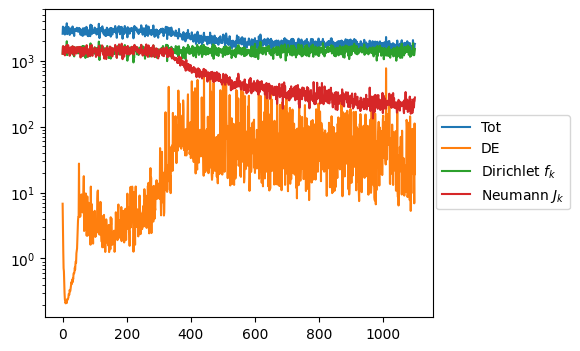

Min DE loss 0.20930828154087067
Min f loss 941.2767887115479
Min J loss 133.0053997039795


In [37]:


# plot_loss_curves(loss_history=trainer.loss_history, case_name='gaussian_inclusion', noise_level_str='0pct')
loss = trainer.loss_history
w = trainer.config['loss_weights']

# for key in loss.keys():
#     print(key)

DE_loss = w['pde'] * np.array(loss['pde'])
f_bc_loss = w['dirichlet_bc'] * np.array(loss['bc'])
J_bc_loss = w['neumann_bc'] * np.array(loss['neumann'])
force_gamma_addloss = w['force_true_gamma'] * np.array(loss['force_true_gamma'])
print(w['force_true_gamma'])
tot_loss = np.array(loss['total'])

# DE_loss =  np.array(loss['pde'])
# f_bc_loss =  np.array(loss['bc'])
# J_bc_loss =  np.array(loss['neumann'])
# tot_loss = np.array(loss['total'])

fig = plt.figure(figsize=(5,4))
plt.plot(tot_loss, label = 'Tot')
plt.plot( DE_loss, label = 'DE')
plt.plot( f_bc_loss, label = r'Dirichlet $f_k$')
plt.plot( J_bc_loss, label = r'Neumann $J_k$')
# plt.plot( force_gamma_addloss, label = r'Force $\gamma_{true}$')

plt.yscale('log')
plt.legend(loc=(1.01,0.35))
plt.show()
fig.savefig(f'{saving_path}/all_losses_epoch_{len(DE_loss)}.pdf')

print('Min DE loss', min(DE_loss[:]))
print('Min f loss', min(f_bc_loss))
print('Min J loss', min(J_bc_loss))


## Analysis

In [38]:
data = trainer.pinn_manager.data

for key in data.keys():
    print(key)

gamma_true
boundary_coords
boundary_potentials
clean_currents
induced_potentials
grid_N
num_bcs


(128, 128)


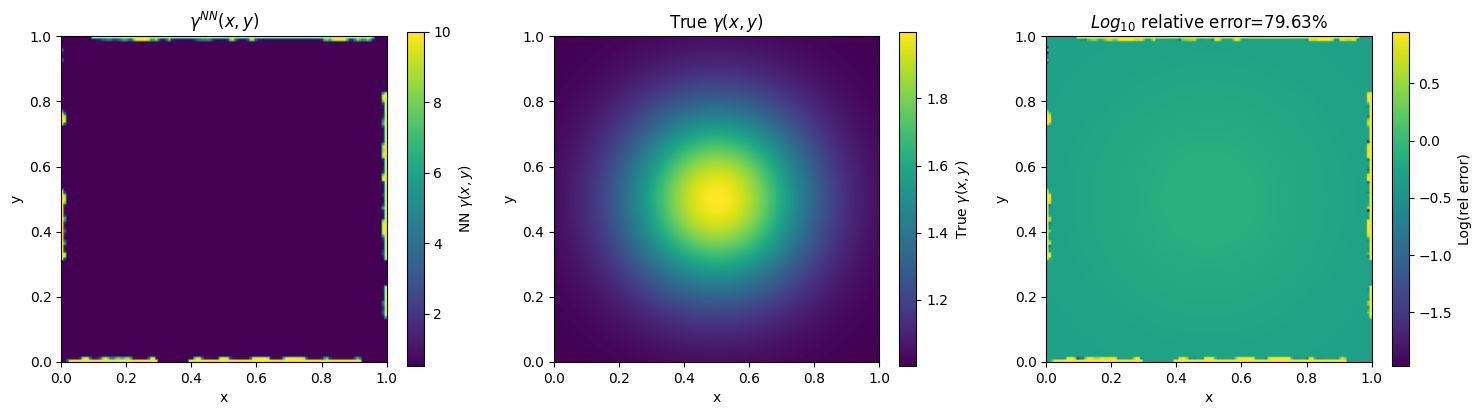

In [39]:
N = 128

gamma_nn = trainer.predict_gamma(N=N)

# 1D coordinates
x = torch.linspace(0, 1, N)
y = torch.linspace(0, 1, N)

# 2D meshgrid
X, Y = torch.meshgrid(x, y, indexing="ij")  # shape (N, N)

# Stack into (N*N, 2) list of coordinates
xy_grid = torch.stack([X.flatten(), Y.flatten()], dim=-1)
gamma_true = load_gamma_interpolator(data['gamma_true'])(xy_grid).reshape(N,N).cpu().detach().numpy()

eps = 1e-12
# rel_error = np.abs((gamma_true - gamma_nn) / (gamma_true + eps))
rel_error = np.log10(np.abs((gamma_true - gamma_nn) / (gamma_true + eps)))
mean_rel_error = np.mean(10**rel_error)
print(gamma_nn.shape)

fig,ax = plt.subplots(1,3,figsize=(15,4))
im0 = ax[0].imshow(gamma_nn, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
# im0 = ax[0].imshow(np.log10(gamma_nn), origin='lower', extent=[0, 1, 0, 1], cmap="viridis")

fig.colorbar(im0, ax=ax[0], label=r"NN $\gamma(x,y)$")
ax[0].set_title(r"$\gamma^{NN}(x,y)$")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

im1 = ax[1].imshow(gamma_true, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
# im1 = ax[1].imshow(np.log10(gamma_true), origin='lower', extent=[0, 1, 0, 1], cmap="viridis")

fig.colorbar(im1, ax=ax[1], label=r"True $\gamma(x,y)$")
ax[1].set_title(r"True $\gamma(x,y)$")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

im2 = ax[2].imshow(rel_error, origin='lower', extent=[0, 1, 0, 1], cmap="viridis")
fig.colorbar(im2, ax=ax[2], label=r"Log(rel error)")
ax[2].set_title(r"$Log_{10}$ relative error="+f'{100*mean_rel_error:.2f}%')
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")

plt.tight_layout()
plt.show()
fig.savefig(f'{saving_path}/gamma_recovered_epoch_{len(DE_loss)}.pdf')



### Single BC analysis

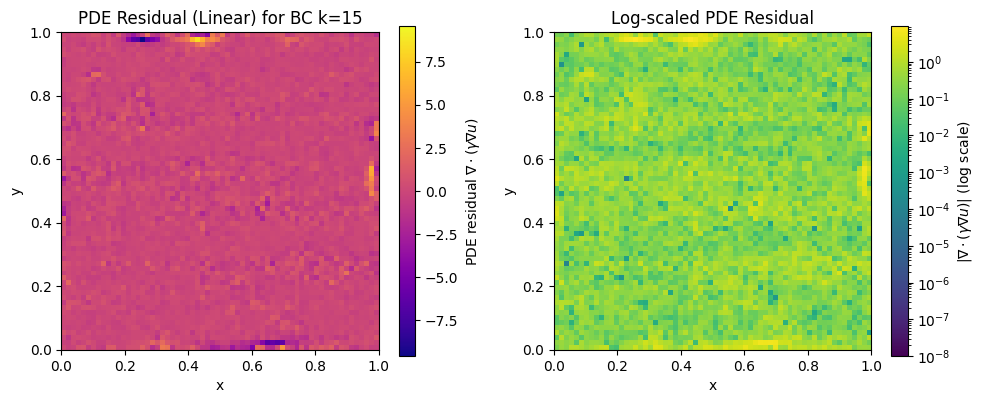

In [54]:
import matplotlib.colors as colors

k_choice = 15  # for example, BC #0

# --- define grid points in [0, 1]² ---
N = 64
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
xx, yy = np.meshgrid(x, y)
xy = np.stack([xx.flatten(), yy.flatten()], axis=1)
xy_torch = torch.tensor(xy, dtype=torch.float32, device=trainer.pinn_manager.device)

# --- create the BC index tensor (same size as xy) ---
k_indices = torch.full((xy_torch.shape[0],), k_choice, dtype=torch.long, device=trainer.pinn_manager.device)

residuals = trainer.pinn_manager.compute_pde_residual(xy_torch.clone().requires_grad_(True), k_indices)

residuals_np = residuals.cpu().detach().numpy().reshape(N, N)

# --- prepare figure ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# === (1) Linear color scale ===
im0 = ax[0].imshow(
    residuals_np,
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="plasma",
    vmin=-np.abs(residuals_np).max(),
    vmax=np.abs(residuals_np).max()
)
fig.colorbar(im0, ax=ax[0], label=r"PDE residual $\nabla \cdot (\gamma \nabla u)$")
ax[0].set_title(fr"PDE Residual (Linear) for BC k={k_choice}")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")

# === (2) Logarithmic color scale ===
eps = 1e-8  # small offset to avoid log(0)
im1 = ax[1].imshow(
    np.abs(residuals_np),
    origin="lower",
    extent=[0, 1, 0, 1],
    cmap="viridis",
    norm=colors.LogNorm(vmin=eps, vmax=np.abs(residuals_np).max())
)
fig.colorbar(im1, ax=ax[1], label=r"$|\nabla \cdot (\gamma \nabla u)|$ (log scale)")
ax[1].set_title(r"Log-scaled PDE Residual")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")

plt.tight_layout()
plt.show()


bnd coords shape torch.Size([252, 2])
N 63
per indx 252


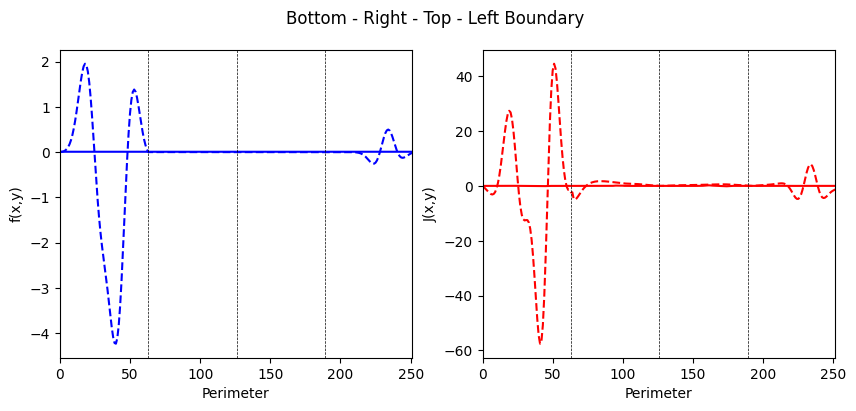

Numerical afine 256
NN afine 252


In [56]:
k = 15

############### Numerical Solution #################

data = np.load(data_filepath)
gamma_true = data["gamma_true"]          # (N, N) conductivity map
bnd_coords_true = data["boundary_coords"]     # (num_boundary_points, 2)
u_all_true = data["induced_potentials"]      # (K, N, N)
f_all_true = data["boundary_potentials"]      # (K, num_boundary_points)
J_all_true = data["clean_currents"]           # (K, num_boundary_points)
N_true = int(data["grid_N"])
# K = int(data["num_bcs"])

x_true, y_true = bnd_coords_true[:,0], bnd_coords_true[:,1]

tol_true = 1e-12
bottom_idx_true = np.where(np.abs(y_true - 0.0) < tol_true)[0]
top_idx_true    = np.where(np.abs(y_true - 1.0) < tol_true)[0]
left_idx_true   = np.where(np.abs(x_true - 0.0) < tol_true)[0]
right_idx_true  = np.where(np.abs(x_true - 1.0) < tol_true)[0]

bottom_idx_true = bottom_idx_true[np.argsort(x_true[bottom_idx_true])]         # left→right
top_idx_true    = top_idx_true[np.argsort(x_true[top_idx_true])][::-1]         # right→left
right_idx_true  = right_idx_true[np.argsort(y_true[right_idx_true])]           # bottom→top
left_idx_true   = left_idx_true[np.argsort(y_true[left_idx_true])][::-1]       # top→bottom

# print(right_idx_true)

perimeter_idx_true = np.concatenate([bottom_idx_true, right_idx_true, top_idx_true, left_idx_true])


f_true = f_all_true[k, perimeter_idx_true]
J_true = J_all_true[k, perimeter_idx_true]

afine_true = np.arange(4*(N_true))


###################### Predicted NN Solution #############

bnd_coords, f_pred, J_pred = trainer.plot_boundary_predictions(dataset, k_idx=k)

N = int(bnd_coords.shape[0]/4)
print('bnd coords shape', bnd_coords.shape)
print('N', N)
K = int(trainer.num_bcs)

x, y = bnd_coords[:,0].cpu().detach().numpy(), bnd_coords[:,1].cpu().detach().numpy()

tol = 1e-12
bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

# print(right_idx)

perimeter_idx = np.concatenate([bottom_idx[:-1], right_idx[:-1], top_idx[:-1], left_idx[:-1]])
print('per indx', len(perimeter_idx))


f_nn = f_pred.cpu().detach().numpy()[perimeter_idx]
#print('f_true', f_true.shape)
J_nn = J_pred.cpu().detach().numpy()[perimeter_idx]
afine = np.arange(4*(N))

############ PLOT ############

fig,ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(afine, f_nn, 'b-', label=r"NN $f(x,y)$")
ax[0].plot(afine_true, f_true, 'b', linestyle = 'dashed', label=r"True $f(x,y)$")
ax[1].plot(afine, J_nn, 'r-', label=r"NN $J(x,y)$")
ax[1].plot(afine_true, J_true, 'r', linestyle = 'dashed', label=r"True $J(x,y)$")
for i in range(1,4):
    ax[0].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
ax[0].set_xlabel('Perimeter')
ax[1].set_xlabel('Perimeter')
ax[0].set_ylabel('f(x,y)')
ax[1].set_ylabel('J(x,y)')
ax[0].set_xlim(left=0, right = 4*N-1)
ax[1].set_xlim(left=0, right = 4*N-1)
plt.suptitle('Bottom - Right - Top - Left Boundary')
plt.show()

fig.savefig(f'{saving_path}/BC_f_and_J_recovered_k_{k}_epoch_{len(DE_loss)}.pdf')

print('Numerical afine', len(afine_true))
print('NN afine', len(afine))


u_all shape (140, 64, 64)


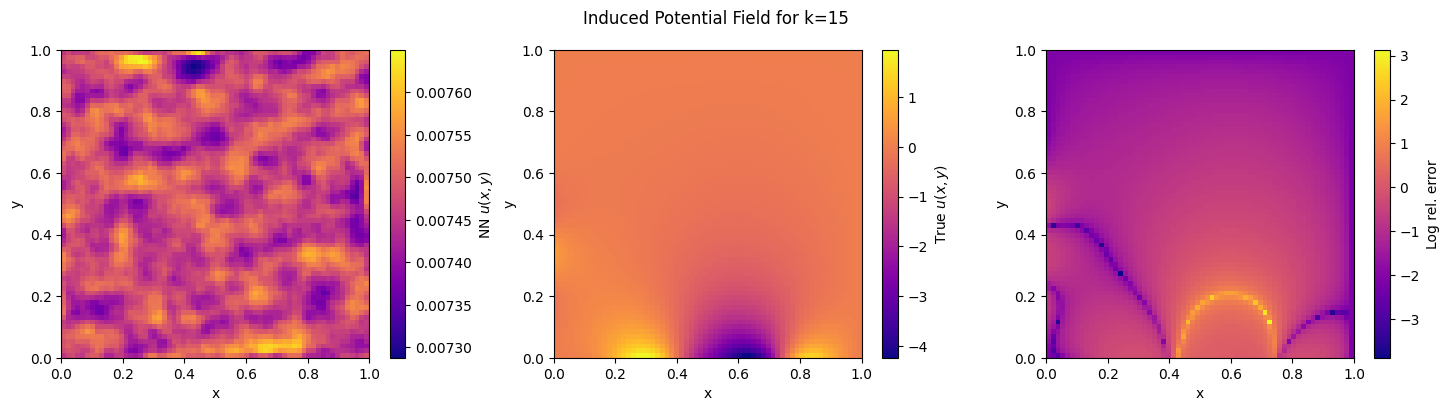

In [58]:
k=15

print('u_all shape', u_all_true.shape)

u_num = u_all_true[k,:,:]

u_nn = trainer.plot_u_field(k_idx=k, N=int(u_all_true.shape[-1]), plot_fig=False).T

rel_error_u = np.log10(np.abs((u_num - u_nn)/(u_num+1)))
# rel_error_u = np.abs((u_num - u_nn)/u_num)

fig, ax = plt.subplots(1,3,figsize=(18,4))
im0 = ax[0].imshow(u_nn, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
fig.colorbar(im0, ax=ax[0], label=r"NN $u(x,y)$")
im1 = ax[1].imshow(u_num, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
fig.colorbar(im1, ax=ax[1], label=r"True $u(x,y)$")
im2 = ax[2].imshow(rel_error_u, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
fig.colorbar(im2, ax=ax[2], label=r"Log rel. error")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
ax[2].set_xlabel("x")
ax[2].set_ylabel("y")
plt.suptitle(rf"Induced Potential Field for k={k}")
fig.savefig(f'{saving_path}/u_induced_k_{k}_compared_epoch_{len(DE_loss)}.pdf')
plt.show()

### All BC

#### Residuals

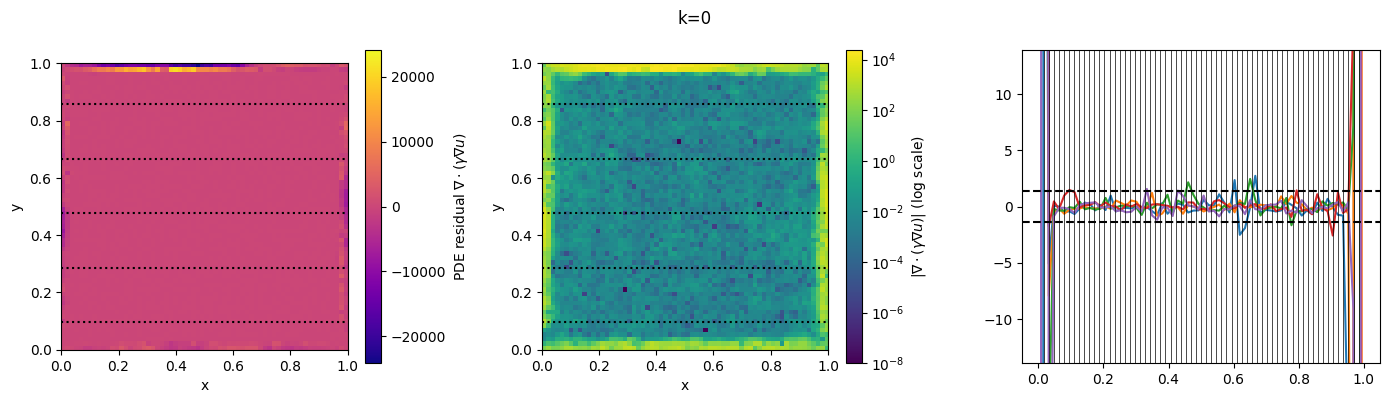

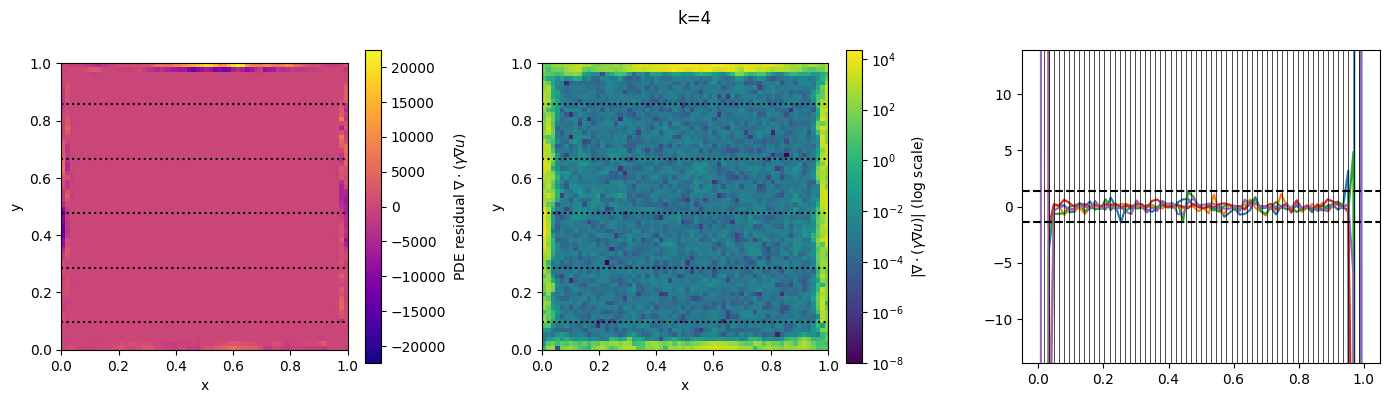

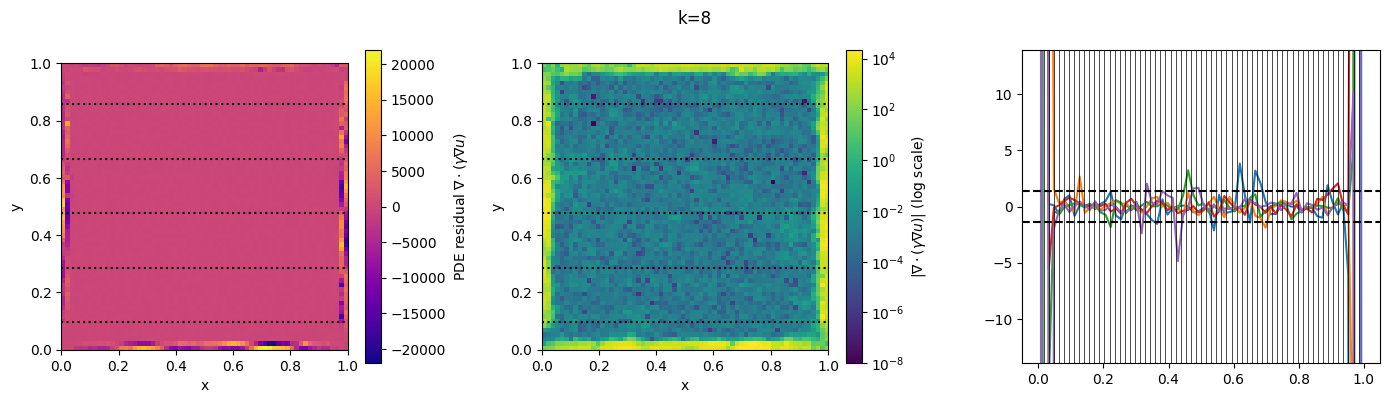

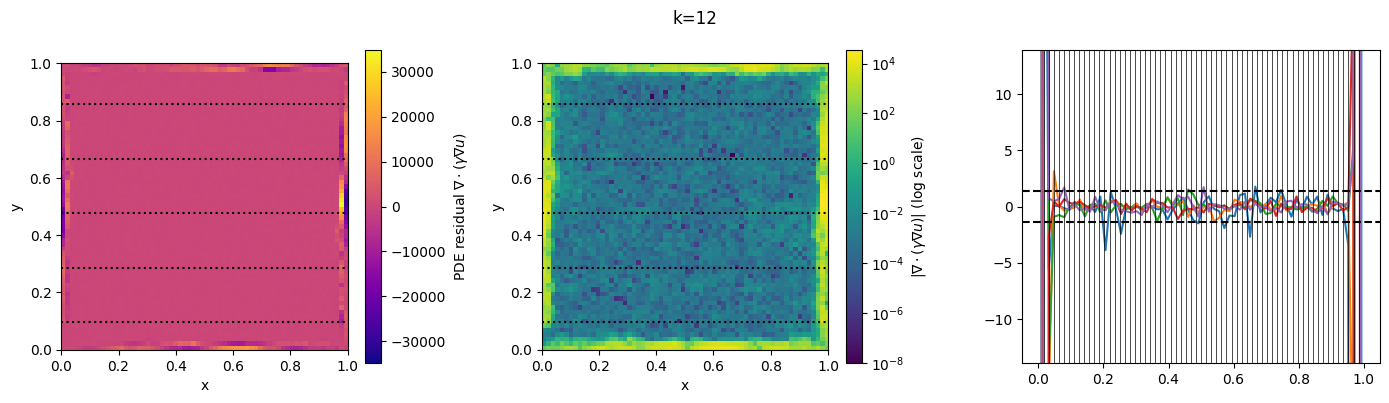

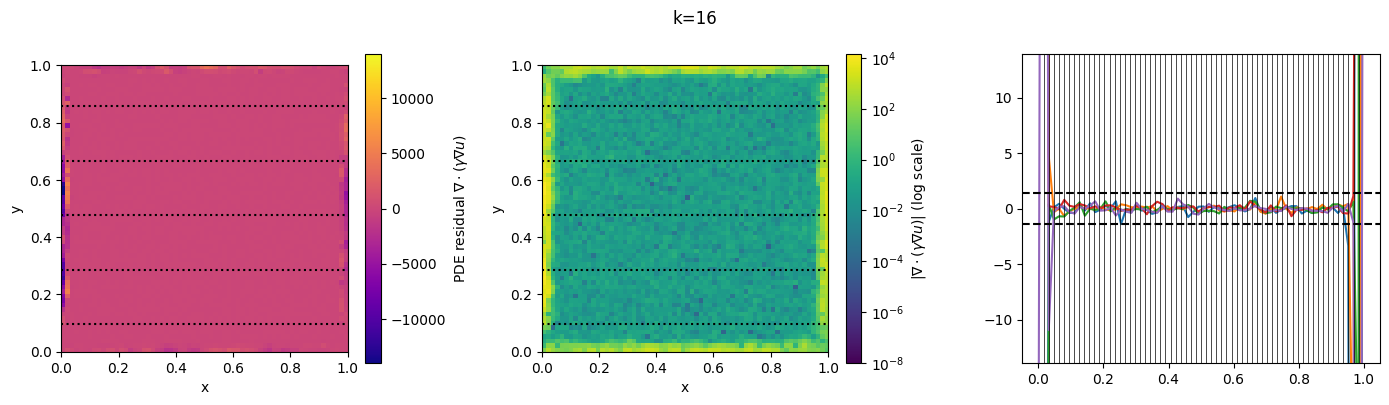

0.09502581882354848


In [60]:
import matplotlib.colors as colors

w = trainer.config['loss_weights']

K = int(trainer.num_bcs)
L = 1.0


k_list = np.arange(K)
for k_choice in k_list:

    if k_choice % int(K/5) == 0:

        N = 64
        x = np.linspace(0, 1, N)
        y = np.linspace(0, 1, N)
        xx, yy = np.meshgrid(x, y)
        xy = np.stack([xx.flatten(), yy.flatten()], axis=1)
        xy_torch = torch.tensor(xy, dtype=torch.float32, device=trainer.pinn_manager.device)

        # --- create the BC index tensor (same size as xy) ---
        k_indices = torch.full((xy_torch.shape[0],), k_choice, dtype=torch.long, device=trainer.pinn_manager.device)

        residuals = trainer.pinn_manager.compute_pde_residual(xy_torch.clone().requires_grad_(True), k_indices)

        residuals_np = residuals.cpu().detach().numpy().reshape(N, N)

        # --- prepare figure ---
        fig, ax = plt.subplots(1, 3, figsize=(14, 4))

        # === (1) Linear color scale ===
        im0 = ax[0].imshow(
            residuals_np,
            origin="lower",
            extent=[0, 1, 0, 1],
            cmap="plasma",
            vmin=-np.abs(residuals_np).max(),
            vmax=np.abs(residuals_np).max()
        )
        fig.colorbar(im0, ax=ax[0], label=r"PDE residual $\nabla \cdot (\gamma \nabla u)$")
        ax[0].set_xlabel("x")
        ax[0].set_ylabel("y")

        # === (2) Logarithmic color scale ===
        eps = 1e-8  # small offset to avoid log(0)
        im1 = ax[1].imshow(
            np.abs(residuals_np),
            origin="lower",
            extent=[0, 1, 0, 1],
            cmap="viridis",
            norm=colors.LogNorm(vmin=eps, vmax=np.abs(residuals_np).max())
        )
        fig.colorbar(im1, ax=ax[1], label=r"$|\nabla \cdot (\gamma \nabla u)|$ (log scale)")
        ax[1].set_xlabel("x")
        ax[1].set_ylabel("y")

        x_vals = np.linspace(0,1,N)
        y_vals = np.linspace(0,1,N)

        for j in range(5):
            res_y_const = residuals_np[:,j*int(N/5)+int(N/10)]

            ax[2].plot(x_vals, res_y_const, color = f'C{j}')
            ax[0].axhline(y_vals[j*int(N/5)+int(N/10)], color=f'k', linestyle = 'dotted')
            ax[1].axhline(y_vals[j*int(N/5)+int(N/10)], color=f'k', linestyle = 'dotted')
        ax[2].axhline(np.sqrt(min(trainer.loss_history['total'])), color = 'k', linestyle='dashed')
        ax[2].axhline(-np.sqrt(min(trainer.loss_history['total'])), color = 'k', linestyle='dashed')
        bound = np.sqrt(min(trainer.loss_history['total'])) * 10
        ax[2].set_ylim(top=bound, bottom=-bound)
        for j in range(N-1):
            ax[2].axvline(L/N * (j+1), color='k', linewidth=0.5, linestyle='solid')

        plt.suptitle(f"k={k_choice}")
        plt.tight_layout()
        plt.show()
print(np.sqrt(min(trainer.loss_history['pde'])))

#### Results

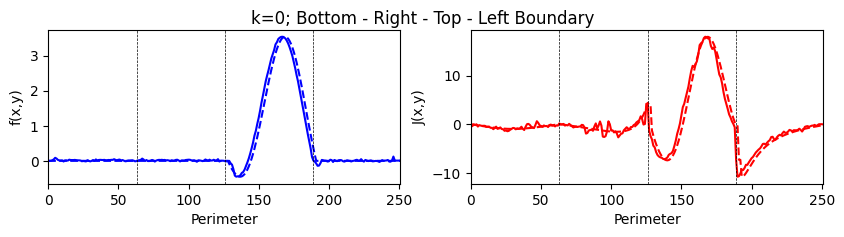

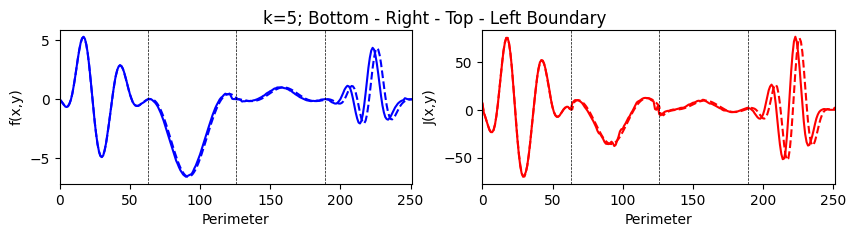

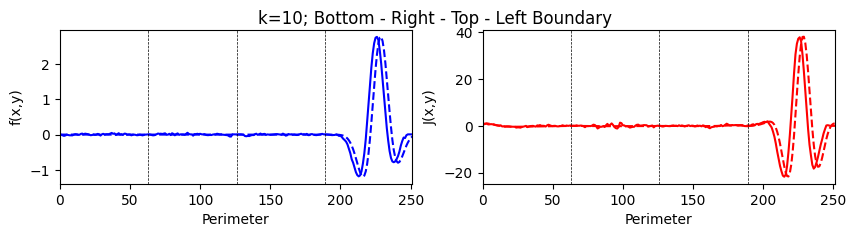

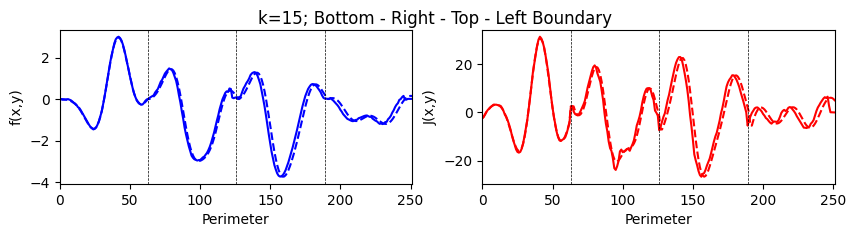

In [62]:
K = int(trainer.num_bcs)

step = 5
k_list = np.arange(K)[::step]

for k in k_list:

    ############### Numerical Solution #################
    data = np.load(data_filepath)
    gamma_true = data["gamma_true"]          # (N, N) conductivity map
    bnd_coords_true = data["boundary_coords"]     # (num_boundary_points, 2)
    u_all_true = data["induced_potentials"]      # (K, N, N)
    f_all_true = data["boundary_potentials"]      # (K, num_boundary_points)
    J_all_true = data["clean_currents"]           # (K, num_boundary_points)
    N_true = int(data["grid_N"])

    x_true, y_true = bnd_coords_true[:,0], bnd_coords_true[:,1]

    tol_true = 1e-12
    bottom_idx_true = np.where(np.abs(y_true - 0.0) < tol_true)[0]
    top_idx_true    = np.where(np.abs(y_true - 1.0) < tol_true)[0]
    left_idx_true   = np.where(np.abs(x_true - 0.0) < tol_true)[0]
    right_idx_true  = np.where(np.abs(x_true - 1.0) < tol_true)[0]

    bottom_idx_true = bottom_idx_true[np.argsort(x_true[bottom_idx_true])]         # left→right
    top_idx_true    = top_idx_true[np.argsort(x_true[top_idx_true])][::-1]         # right→left
    right_idx_true  = right_idx_true[np.argsort(y_true[right_idx_true])]           # bottom→top
    left_idx_true   = left_idx_true[np.argsort(y_true[left_idx_true])][::-1]       # top→bottom

    perimeter_idx_true = np.concatenate([bottom_idx_true, right_idx_true, top_idx_true, left_idx_true])
    f_true = f_all_true[k, perimeter_idx_true]
    J_true = J_all_true[k, perimeter_idx_true]
    afine_true = np.arange(4*(N_true))

    ###################### Predicted NN Solution #############
    bnd_coords, f_pred, J_pred = trainer.plot_boundary_predictions(dataset, k_idx=k)

    N = int(bnd_coords.shape[0]/4)
    # K = int(trainer.num_bcs)
    x, y = bnd_coords[:,0].cpu().detach().numpy(), bnd_coords[:,1].cpu().detach().numpy()

    tol = 1e-12
    bottom_idx = np.where(np.abs(y - 0.0) < tol)[0]
    top_idx    = np.where(np.abs(y - 1.0) < tol)[0]
    left_idx   = np.where(np.abs(x - 0.0) < tol)[0]
    right_idx  = np.where(np.abs(x - 1.0) < tol)[0]

    bottom_idx = bottom_idx[np.argsort(x[bottom_idx])]         # left→right
    top_idx    = top_idx[np.argsort(x[top_idx])][::-1]         # right→left
    right_idx  = right_idx[np.argsort(y[right_idx])]           # bottom→top
    left_idx   = left_idx[np.argsort(y[left_idx])][::-1]       # top→bottom

    perimeter_idx = np.concatenate([bottom_idx[:-1], right_idx[:-1], top_idx[:-1], left_idx[:-1]])
    f_nn = f_pred.cpu().detach().numpy()[perimeter_idx]
    J_nn = J_pred.cpu().detach().numpy()[perimeter_idx]
    afine = np.arange(4*(N))

    fig,ax = plt.subplots(1,2, figsize=(10,2))
    ax[0].plot(afine, f_nn, 'b-', label=r"NN $f(x,y)$")
    ax[0].plot(afine_true, f_true, 'b', linestyle = 'dashed', label=r"True $f(x,y)$")
    ax[1].plot(afine, J_nn, 'r-', label=r"NN $J(x,y)$")
    ax[1].plot(afine_true, J_true, 'r', linestyle = 'dashed', label=r"True $J(x,y)$")
    for i in range(1,4):
        ax[0].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
        ax[1].axvline(i*N, color='k', linestyle='--', linewidth=0.5)
    ax[0].set_xlabel('Perimeter')
    ax[1].set_xlabel('Perimeter')
    ax[0].set_ylabel('f(x,y)')
    ax[1].set_ylabel('J(x,y)')
    ax[0].set_xlim(left=0, right = 4*N-1)
    ax[1].set_xlim(left=0, right = 4*N-1)
    plt.suptitle(f'k={k}; Bottom - Right - Top - Left Boundary')
    plt.show()

    # fig.savefig(f'{saving_path}/BC_f_and_J_recovered_k_{k}_epoch_{len(DE_loss)}.pdf')



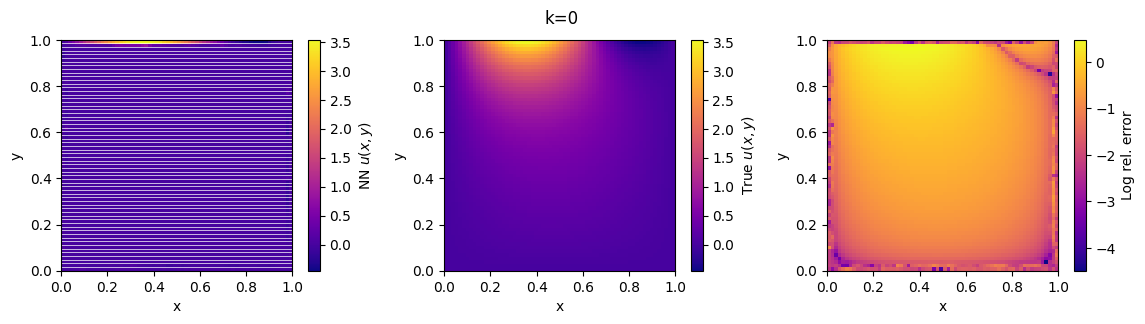

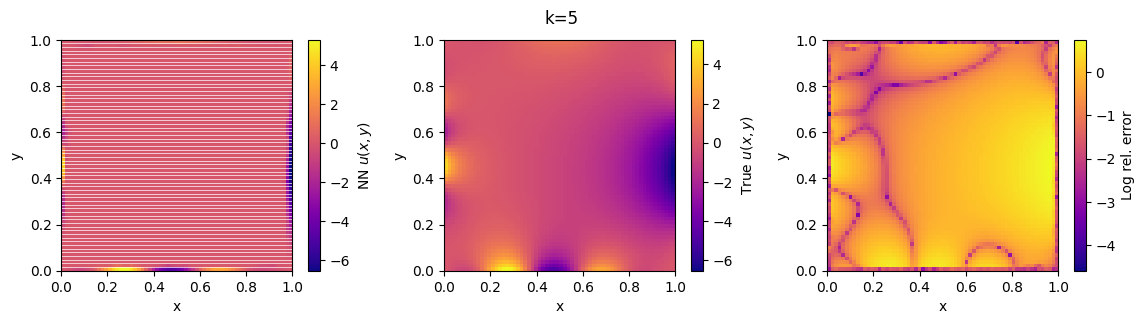

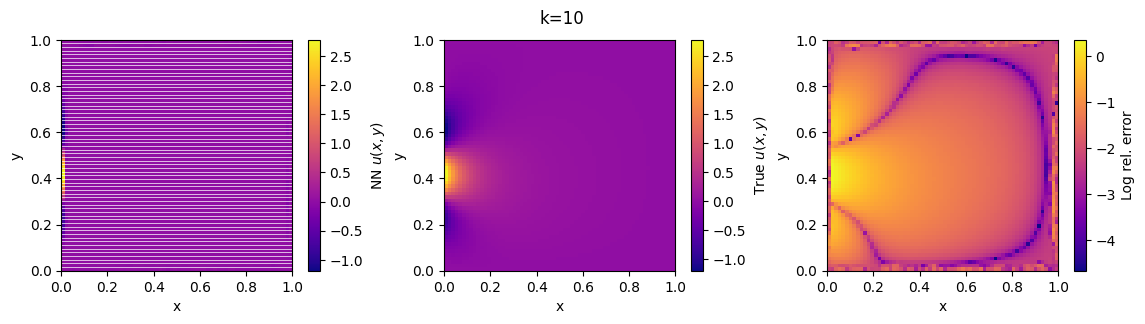

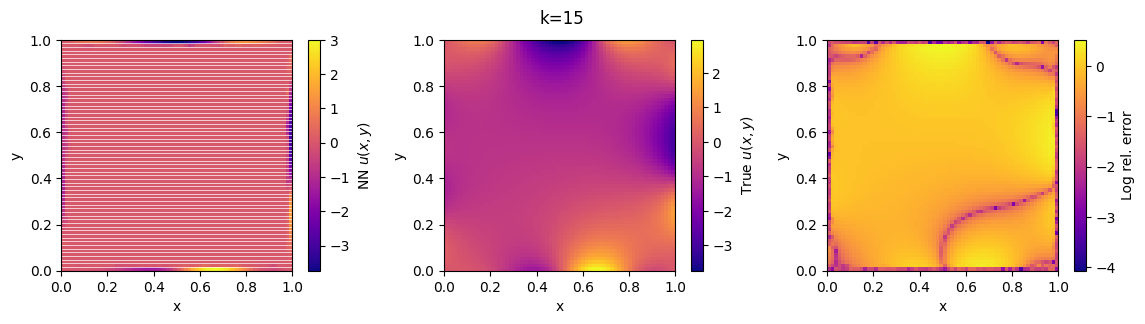

In [68]:
step = 5

k_list = np.arange(K)[::step]

for k in k_list:

    u_num = u_all_true[k,:,:]

    u_nn = trainer.plot_u_field(k_idx=k, N=int(u_all_true.shape[-1]), plot_fig=False).T

    eps = 1e-5

    # rel_error_u = np.log10(np.abs((u_num - u_nn)/(u_num+eps)))
    rel_error_u = np.log10(np.abs((u_num - u_nn)))
    # rel_error_u = np.abs((u_num - u_nn)/(u_num+1))

    fig, ax = plt.subplots(1,3,figsize=(14,3))
    im0 = ax[0].imshow(u_nn, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    fig.colorbar(im0, ax=ax[0], label=r"NN $u(x,y)$")

    for j in range(N-1):
        ax[0].axhline(L/N * (j+1), color='white', linewidth=0.5, linestyle='solid')

    im1 = ax[1].imshow(u_num, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    fig.colorbar(im1, ax=ax[1], label=r"True $u(x,y)$")
    im2 = ax[2].imshow(rel_error_u, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
    fig.colorbar(im2, ax=ax[2], label=r"Log rel. error")
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    ax[1].set_xlabel("x")
    ax[1].set_ylabel("y")
    ax[2].set_xlabel("x")
    ax[2].set_ylabel("y")
    plt.suptitle(rf"k={k}")
    # fig.savefig(f'{saving_path}/u_induced_k_{k}_compared_epoch_{len(DE_loss)}.pdf')
    plt.show()

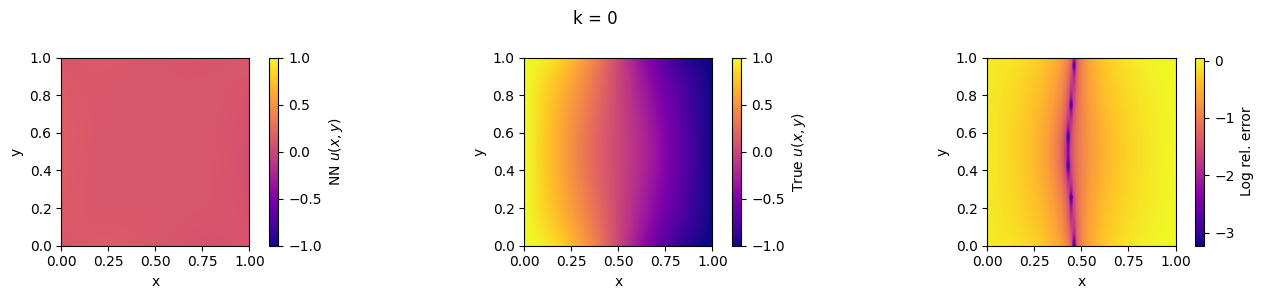

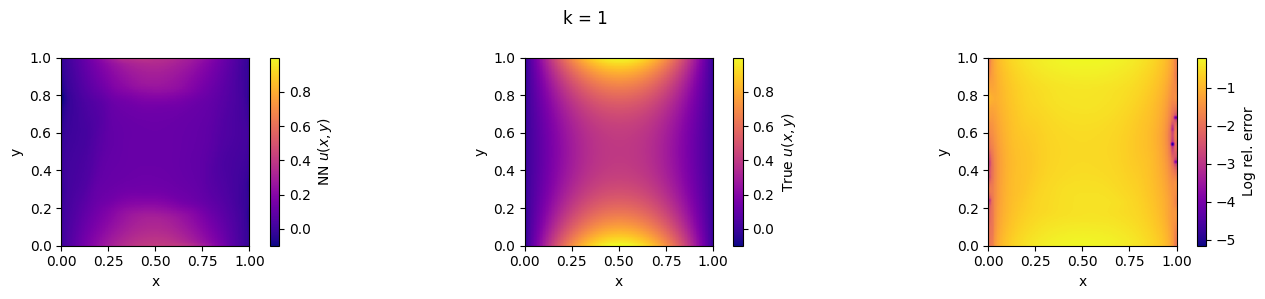

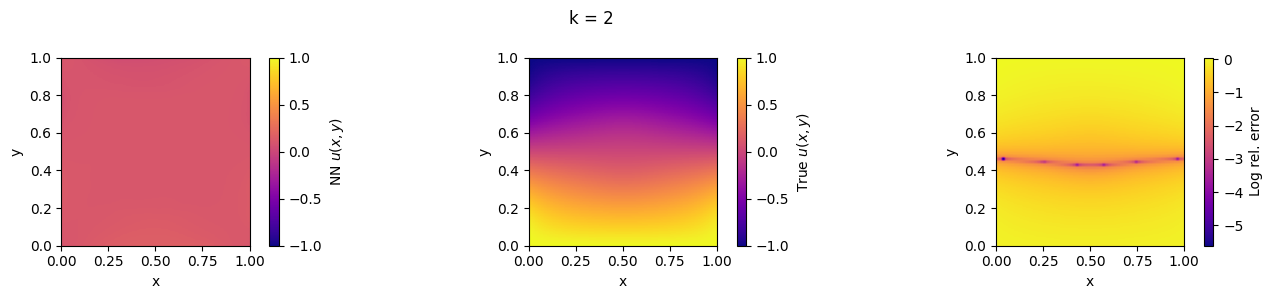

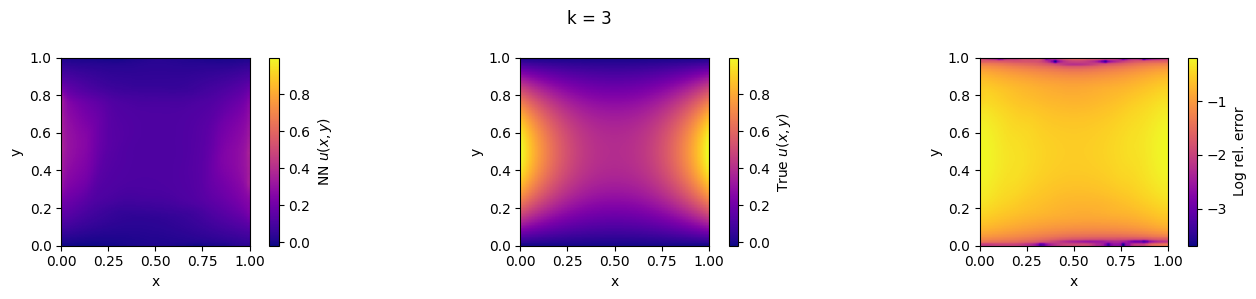

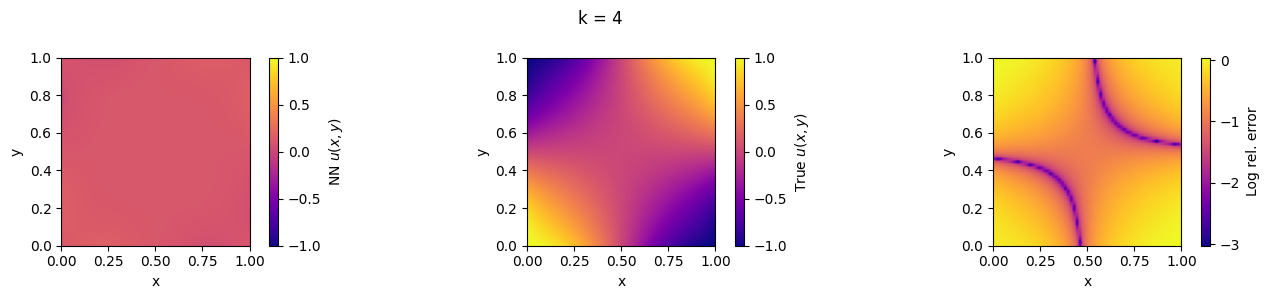

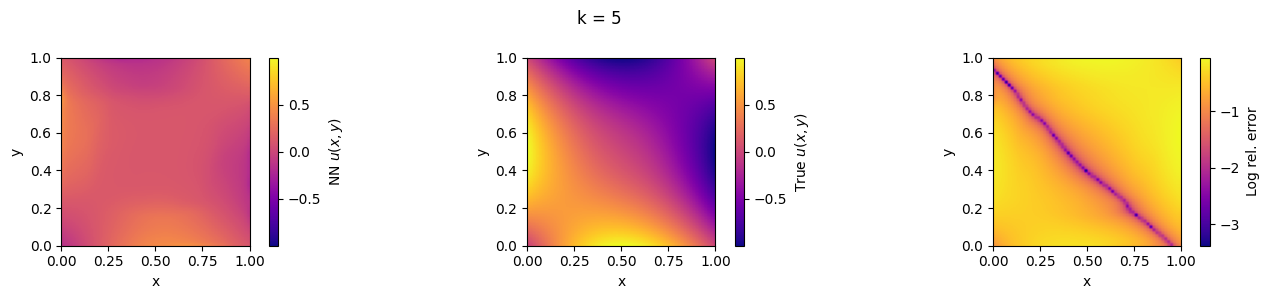

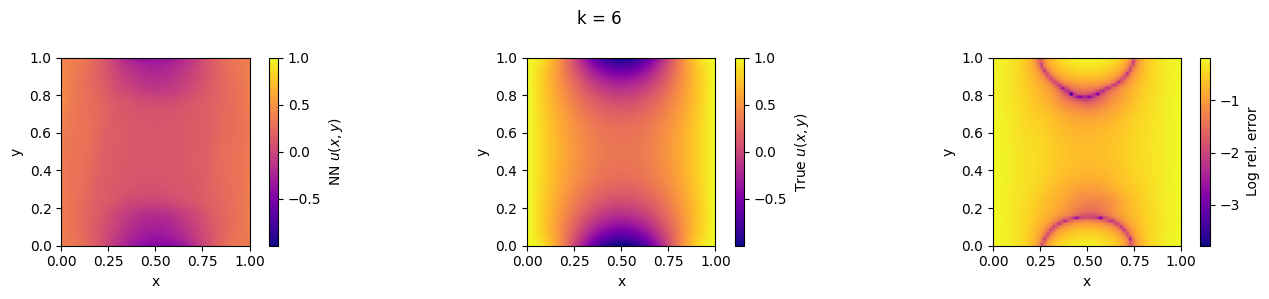

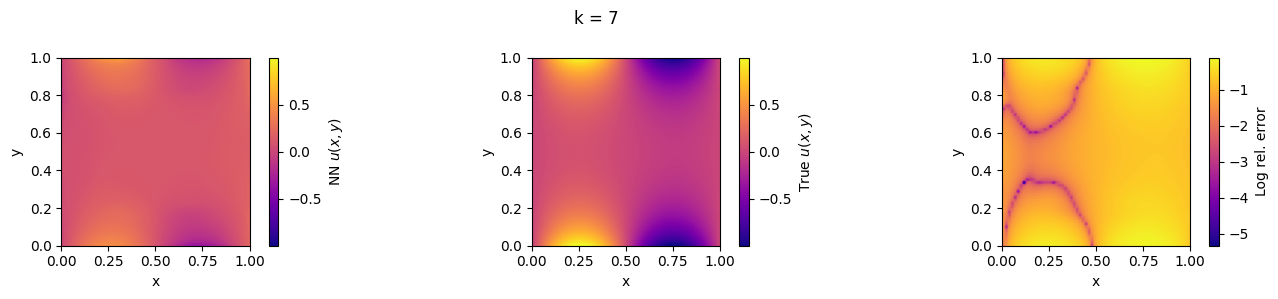

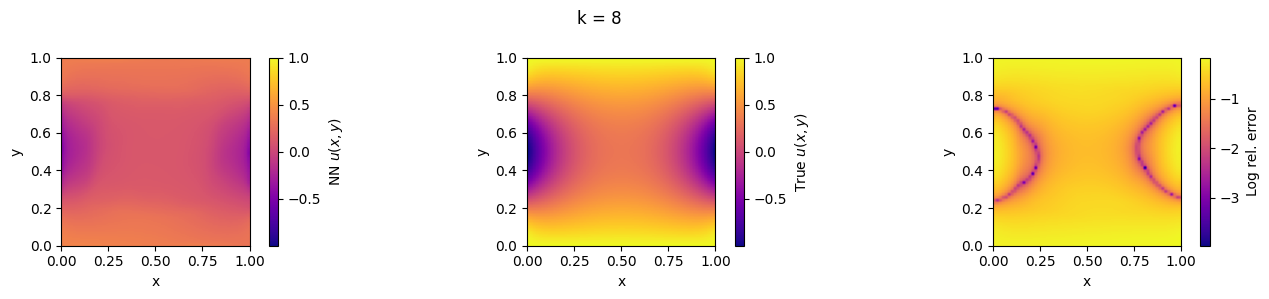

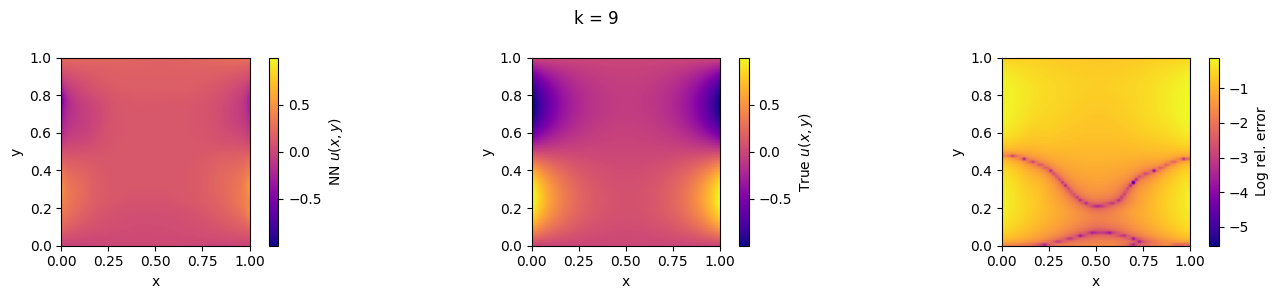

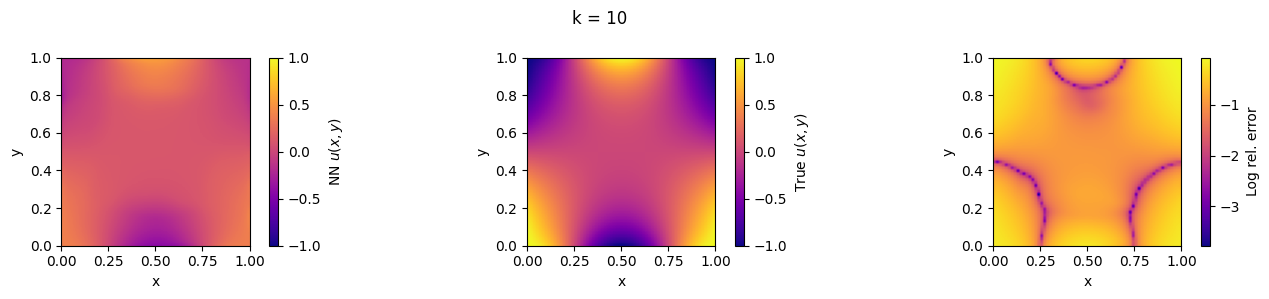

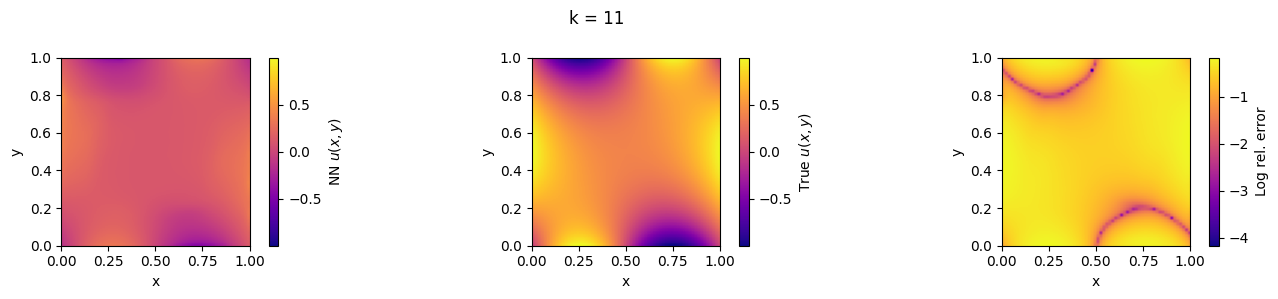

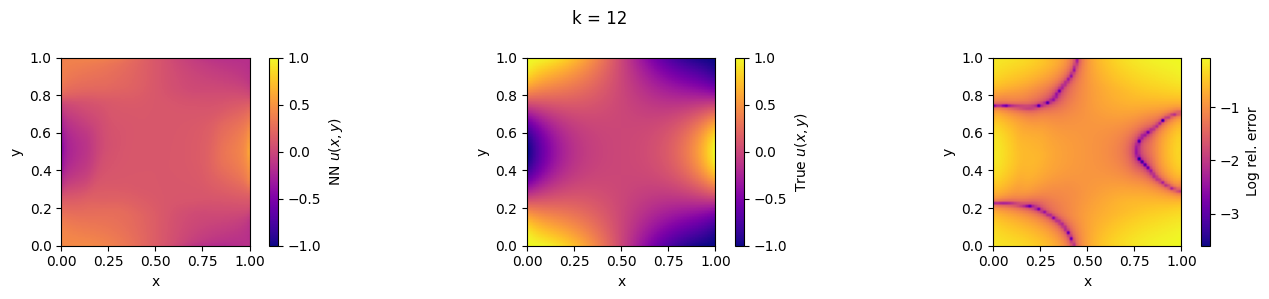

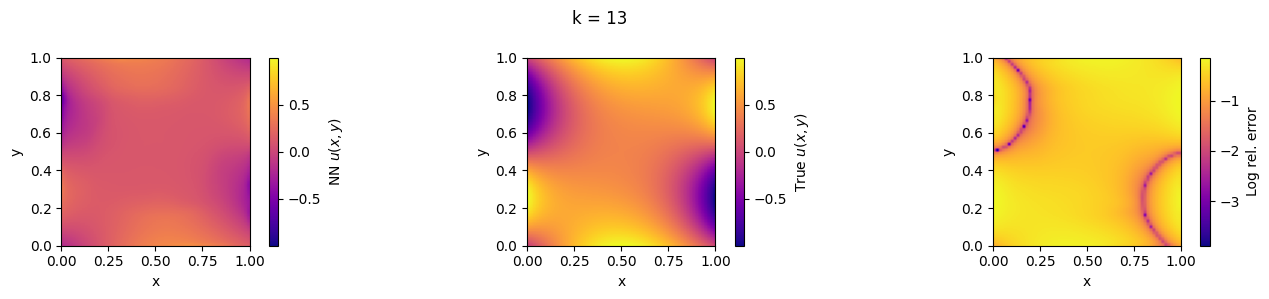

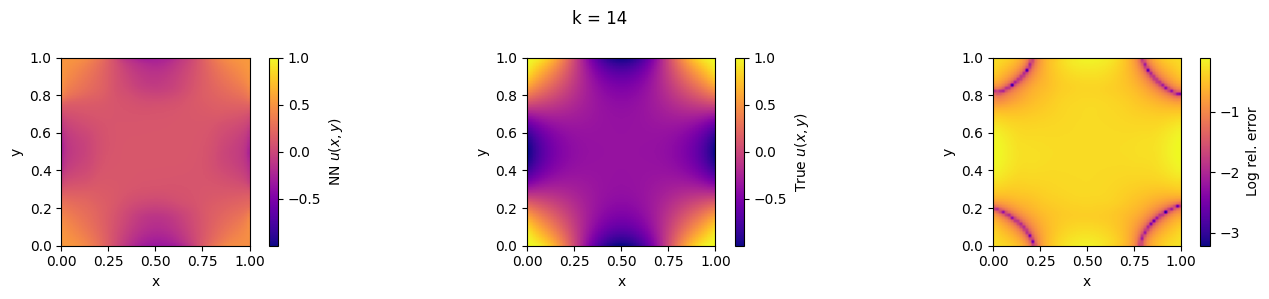

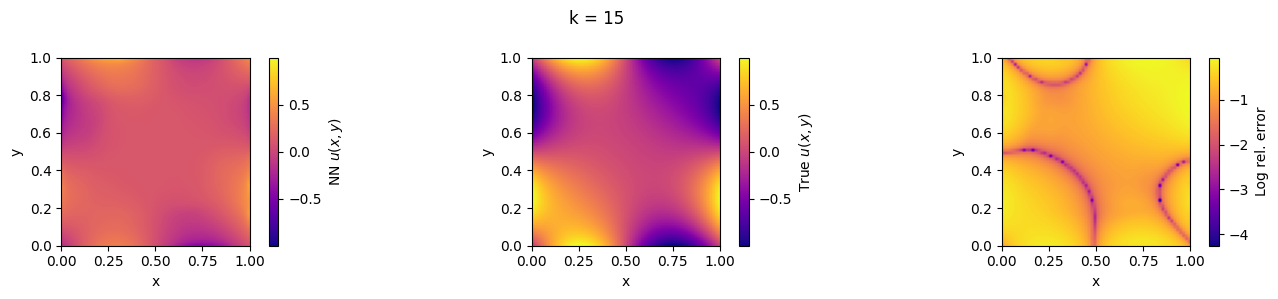

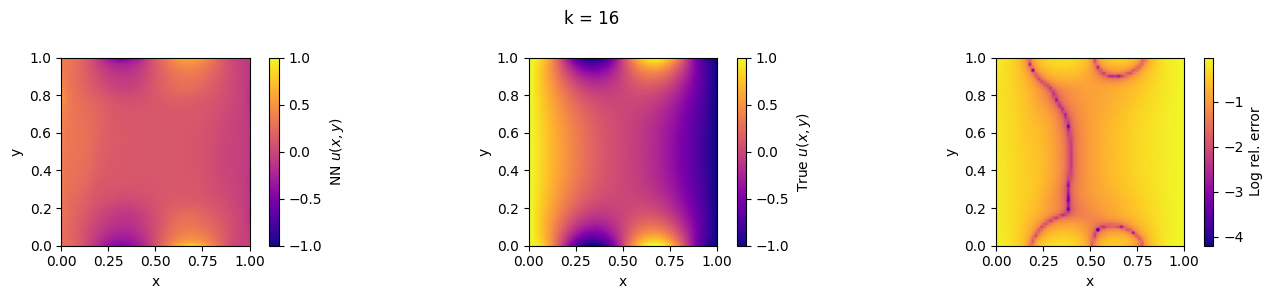

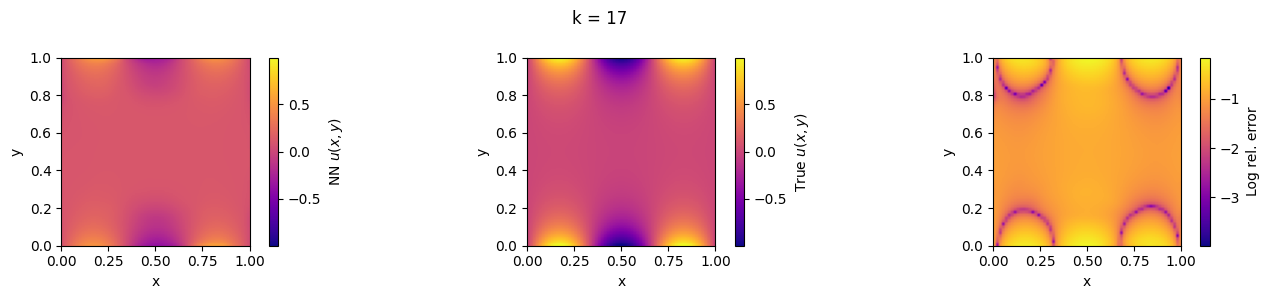

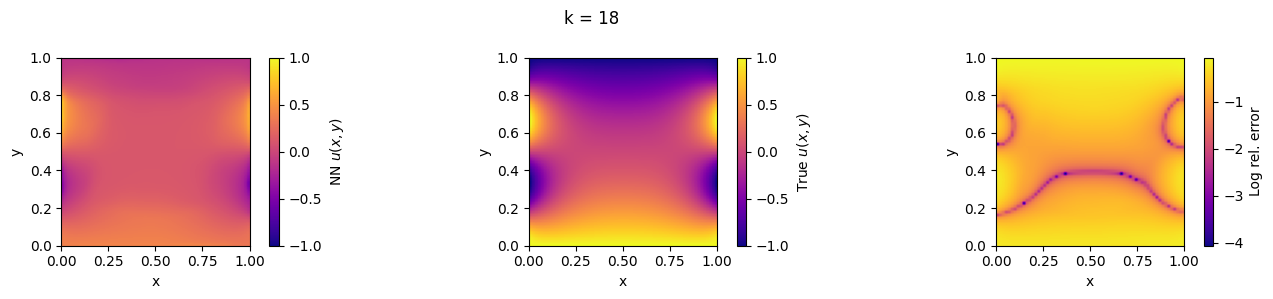

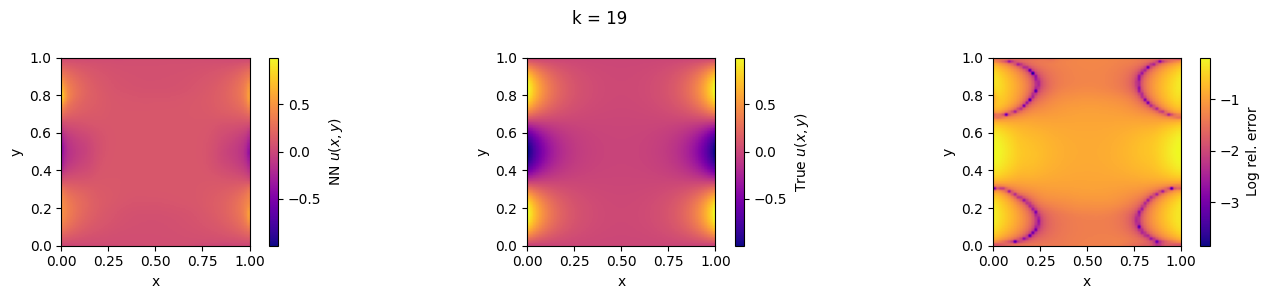

In [75]:
k_list = np.arange(K)

for k in k_list:

    u_num = u_all_true[k, :, :]
    u_nn = plot_u_field(trainer, k_idx=k, N=int(u_all_true.shape[-1]), plot_fig=False).T

    # Log-scale relative error
    rel_error_u = np.log10(np.abs((u_num - u_nn)))

    # --- Find common vmin/vmax for u plots ---
    vmin = min(u_nn.min(), u_num.min())
    vmax = max(u_nn.max(), u_num.max())

    fig, ax = plt.subplots(1, 3, figsize=(14, 3))

    # --- NN solution ---
    im0 = ax[0].imshow(u_nn, origin='lower', extent=[0, 1, 0, 1],
                       cmap='plasma', vmin=vmin, vmax=vmax)
    fig.colorbar(im0, ax=ax[0], label=r"NN $u(x,y)$")

    # --- True solution ---
    im1 = ax[1].imshow(u_num, origin='lower', extent=[0, 1, 0, 1],
                       cmap='plasma', vmin=vmin, vmax=vmax)
    fig.colorbar(im1, ax=ax[1], label=r"True $u(x,y)$")

    # --- Log relative error ---
    im2 = ax[2].imshow(rel_error_u, origin='lower', extent=[0, 1, 0, 1],
                       cmap='plasma')
    fig.colorbar(im2, ax=ax[2], label=r"Log rel. error")

    # --- Labels and layout ---
    for i in range(3):
        ax[i].set_xlabel("x")
        ax[i].set_ylabel("y")

    plt.suptitle(rf"k = {k}")
    plt.tight_layout()
    plt.show()


#### Sampling more towards the center:

$$ w(x,y) = (1 + \rho \cdot(1-2|x-0.5|)) \times (1 + \rho \cdot(1-2|y-0.5|)) $$

where $\rho$ is the relative density of points towards the center with respect to the near-boundary region. 

Note: if $\rho=1\Rightarrow w(x,y)=1\,\,\,\forall\,(x,y)\in\Omega$

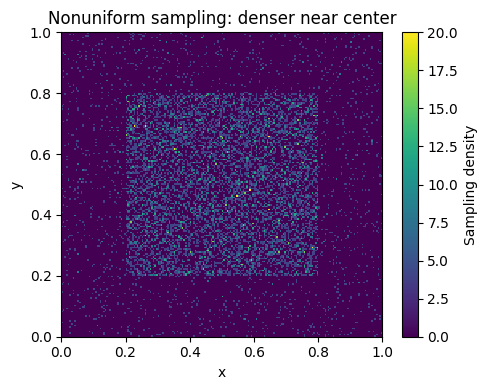

torch.Size([10000, 2])


In [ ]:
device = 'cpu'
batch_size = 10000
# xy_dense = trainer.sample_dense_center_square(batch_size, device=device, density_factor=10, center_bounds=(0.2, 0.8))
xy_dense = trainer.sample_dense_center_square(batch_size, device=device, density_factor=trainer.config['density_factor'], center_bounds=(0.2, 0.8))
xy_dense_np = xy_dense.cpu().numpy()

# ==== Plot density heatmap ====
plt.figure(figsize=(5, 4))
plt.hist2d(
    xy_dense_np[:, 0],
    xy_dense_np[:, 1],
    bins=200,
    range=[[0, 1], [0, 1]],
    cmap='viridis',
    density=True
)
plt.colorbar(label='Sampling density')
plt.title("Nonuniform sampling: denser near center")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()
print(xy_dense.shape)

In [163]:
# k=0

# i = 0
# for bnd_batch_cpu in dataloader:
#     print(i)
#     i += 1
#     # Move batch to device
#     bnd_batch = [t.to(trainer.device) for t in bnd_batch_cpu]
#     xy_bnd, k_bnd, normals_bnd, f_bnd, J_bnd = bnd_batch
#     print(xy_bnd.shape)
#     xy_mock = xy_bnd.reshape(4*31, 5,2)
#     print(xy_mock.shape)
#     k_mock = k_bnd.reshape(4*31, 5)
#     print('normals',normals_bnd.shape)
#     normals_mock = normals_bnd.reshape(4*31, 5,2)

#     k_one_hot = pinn_manager._to_one_hot(k_indices=k_mock[:,k], num_classes=trainer.num_bcs)

#     pde_batch = (xy_mock[:,k,:], k_one_hot)

# u_pred, J_pred = pinn_manager.compute_data_predictions(xy_mock[:,k,:], k_one_hot, normals_mock[:,k,:])

# k=0

# print('u_pred shape', u_pred.shape)

# u_ex = u_pred.cpu().detach().numpy()

# fig = plt.figure(figsize=(4,4))
# im1 = plt.imshow(u_ex, origin='lower', extent=[0, 1, 0, 1], cmap='plasma')
# plt.title(r"Induced Potential Field ")
# plt.xlabel("x")
# plt.ylabel("y")
# fig.colorbar(im1, label=r'$u_0(x,y)$', orientation='vertical')
# plt.show()